In [1]:
### tdann prop analysis
# prop selective units in each layer
# prop weight map in simulated cortex
# plsr between brain and tdann
# classification using plsr predicted features

### prop selective units in each layer

In [1]:
# model prediction performance

import h5py 
import numpy as np
from os.path import join as pjoin

basedir = r'/n02dat01/users/qdzhao/THINGS'
fdir = pjoin(basedir, r'property_analysis/derivatives/cnn-som/prop-pcs_tdann')

pro_nm = ['manmade', 'precious', 'animacy', 'heavy', 'natural', 'moves',
           'grasp', 'hold','be_moved', 'pleasant', 'deprecatedArousing', 'size']
lys = ['layer1.0','layer1.1','layer2.0','layer2.1','layer3.0','layer3.1','layer4.0','layer4.1'] # tdann layers
# lys_ = 


In [2]:
# threshold of predicted r for each model lys
# this threshold is derived from model training process
# in training, the minimum r in sifnificant adj_p(<0.05) set

# 下面分析训练集上可显著预测的区域的r值分布
# 然后将该r的最小值作为 model performance的阈值。
import scipy.io as scio

corr_model = []
thrhd_model = [] # threshold of r for each ly
for i in range(8):
    
    # real model activation
    outdir = pjoin(basedir, r'property_analysis/data/cnn-som/prop-pcs_tdann',lys[i])
    model_act = scio.loadmat(pjoin(outdir, f'img_tdann_720.mat')) # 'model_train':model_train,'model_test':model_test
    prop_pcs = scio.loadmat(pjoin(outdir, f'obj720_pro_pcs.mat')) # 'prop_train':prop_train,'prop_test':prop_test
    model_act_tr = model_act['model_train']
    print(model_act_tr.shape)
    prp_pcs_tr = prop_pcs['prop_train']
    print(prp_pcs_tr.shape)

    # predicted model activation
    wei_f = pjoin(fdir, lys[i], f'encoding_training_result.mat')
    weigh = h5py.File(wei_f)
    print(weigh.keys())
    weigh_mrx = weigh['thetaFinal']
    weigh_mrx = np.array(weigh_mrx)
    print('transform matrix shape ', weigh_mrx.shape) # (U,5)

    # corr (real, prdicted)
    model_act_tr_pred = np.dot(prp_pcs_tr,weigh_mrx.T)

    # sigf mask
    # p value of training set
    adjp_f = pjoin(fdir, lys[i],f'cross_validation_permutation_result.mat')
    adjp = h5py.File(adjp_f)
    #     print(adjp.keys())
    adjp_ = adjp['adj_p']
    adj_p = np.squeeze(adjp_)

    # significant r with p < .05
    idx_adjp = []
    for j in range(len(adj_p)):
        if adj_p[j]<0.05:
            idx_adjp.append(j)

    corr = []
    x = model_act_tr.T[idx_adjp]
    y = model_act_tr_pred.T[idx_adjp]
    for i in range(len(idx_adjp)):
        tmp_r = np.corrcoef(x[i],y[i])[0,1]
        corr.append(tmp_r)
    corr = np.array(corr)
    corr_model.append(corr)
    print(np.max(corr[~np.isnan(corr)]))
    print(np.min(corr[~np.isnan(corr)]))
    thrhd_model.append(np.min(corr[~np.isnan(corr)])) # 忽略corr中的nan
print(thrhd_model)
outdir = pjoin(basedir, r'property_analysis/derivatives/cnn-som/prop-pcs_tdann')
np.savez(pjoin(outdir,'threshold_r.npz'),label = thrhd_model)

(648, 200704)
(648, 5)
<KeysViewHDF5 ['CV', 'reguFinal', 'thetaFinal', 'thetaRecord', 'validSquaError']>
transform matrix shape  (200704, 5)


/share/home/qdzhao/.local/lib/python3.8/site-packages/numpy/lib/function_base.py:2829: RuntimeWarning: invalid value encountered in true_divide
  c /= stddev[:, None]


0.603852542337173
0.004999115625696127
(648, 200704)
(648, 5)
<KeysViewHDF5 ['CV', 'reguFinal', 'thetaFinal', 'thetaRecord', 'validSquaError']>
transform matrix shape  (200704, 5)
0.5681733422487683
0.018574039165130746
(648, 100352)
(648, 5)
<KeysViewHDF5 ['CV', 'reguFinal', 'thetaFinal', 'thetaRecord', 'validSquaError']>
transform matrix shape  (100352, 5)
0.5672155660906831
0.08775276502339283
(648, 100352)
(648, 5)
<KeysViewHDF5 ['CV', 'reguFinal', 'thetaFinal', 'thetaRecord', 'validSquaError']>
transform matrix shape  (100352, 5)
0.6437759546782281
0.1095799123968556
(648, 50176)
(648, 5)
<KeysViewHDF5 ['CV', 'reguFinal', 'thetaFinal', 'thetaRecord', 'validSquaError']>
transform matrix shape  (50176, 5)
0.7131973804859212
0.03829273798972506
(648, 50176)
(648, 5)
<KeysViewHDF5 ['CV', 'reguFinal', 'thetaFinal', 'thetaRecord', 'validSquaError']>
transform matrix shape  (50176, 5)
0.7597844741325323
0.10417576197965844
(648, 25088)
(648, 5)
<KeysViewHDF5 ['CV', 'reguFinal', 'thetaFin

findfont: Font family ['Arial'] not found. Falling back to DejaVu Sans.


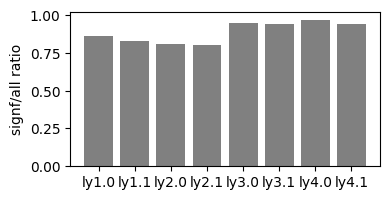

In [2]:
# load threshold r of each lys
thrhd = np.load(pjoin(fdir,'threshold_r.npz'))
thrhd_ = thrhd['label']

ratio = []
for i in range(8):
    adjp_f = pjoin(fdir, lys[i],f'cross_validation_permutation_result.mat')
    adjp = h5py.File(adjp_f)
    #     print(adjp.keys())
    adjp_ = adjp['adj_p']
    adj_p = np.squeeze(adjp_)

    ped_r_f = pjoin(fdir, lys[i],f'model_test_result.mat')
    ped_r = h5py.File(ped_r_f)
    #     print(ped_r.keys())
    acc_r = ped_r['R']
    acc_r_ = np.squeeze(acc_r)
    acc_r = np.nan_to_num(acc_r_)
    #     print(acc_r.shape)
    count = 0
    for j in range(adj_p.shape[0]):
        if adj_p[j]<0.05 and acc_r[j]>thrhd_[i]:
            count+=1
    rto = round((count/adj_p.shape[0]),2)
    ratio.append(rto)
    
import matplotlib.pyplot as plt
lyss = ['ly1.0','ly1.1','ly2.0','ly2.1','ly3.0','ly3.1','ly4.0','ly4.1']
x = range(8)
plt.figure(figsize=(4,2)) # ,dpi=300
plt.rc('font',family='Arial', size=10)
plt.bar(x,ratio,color="gray")
font_dict = {'family':'Arial', 'size':10}
plt.xticks(x,labels=lyss,fontproperties=font_dict)
# plt.xlabel('Cluster',fontdict=font_dict)
plt.ylabel('signf/all ratio',fontdict=font_dict)
# plt.ylim([0,0.4])
# plt.legend(loc='best',prop=font_dict)
# plt.title('ROI prop selection')
plt.show()

In [ ]:
# prediction accuracy correlation r histogram
import matplotlib.pyplot as plt

i = 6
adjp_f = pjoin(fdir, lys_[i],f'cross_validation_permutation_result.mat')
adjp = h5py.File(adjp_f)
#     print(adjp.keys())
adjp_ = adjp['adj_p']
adj_p = np.squeeze(adjp_)

ped_r_f = pjoin(fdir, lys_[i],f'model_test_result.mat')
ped_r = h5py.File(ped_r_f)
#     print(ped_r.keys())
acc_r = ped_r['R']
acc_r_ = np.squeeze(acc_r)
acc_r = np.nan_to_num(acc_r_)
#     print(acc_r.shape)
print(np.max(acc_r),np.min(acc_r)) # why nan
print(np.mean(acc_r))

# significant r with p < .05
cor_r = []
for j in range(len(acc_r)):
    if adj_p[j]<0.05 and acc_r[j]>thrhd_[i]:
        cor_r.append(acc_r[j])
# cor_r= np.where(adj_p<0.05,acc_r,0)
# som_plot(cor_r,'test_perf_signif_r', dmax=np.max(cor_r))

lyss = ['ly1','ly2','ly3','ly4']
# plot:
fig, ax = plt.subplots(figsize=(2,1.5))
plt.rc('font',family='Arial', size=10)
cor_r = np.array(cor_r)
print('cor_r count is: ',len(cor_r))
ax.hist(cor_r, bins=20, linewidth=0.5, edgecolor="white",color="gray")

font_dict = {'family':'Arial', 'size':10}
ax.set(xlim=(0, 0.7), xticks=np.linspace(0, 0.7, 8),
       ylim=(0, 400), yticks=np.linspace(0, 400, 5))
plt.xlabel(lyss[i]+' r',fontproperties=font_dict)
plt.ylabel('frequency',fontproperties=font_dict)
plt.show()
# out_png = pjoin(fdir,lys_[i]+'\plot',f'corrected_r-histogram.png')
# fig.savefig(out_png, dpi=300)


### property map in simulated cortex

In [2]:
import os
import sys
from os.path import join as pjoin
basedir = r'/n02dat01/users/qdzhao/THINGS'
code_path = pjoin(basedir, r'property_analysis/code/cnn-som/TDANN/TDANN-main')
positions_dir = pjoin(basedir, r'property_analysis/code/cnn-som/TDANN', r'tdann_data/tdann/positions/simclr_spatial_resnet18_fuzzy_swappedon_SineGrating2019_lw0/resnet18_retinotopic_init_fuzzy_swappedon_SineGrating2019_NBVER2')

sys.path.append(code_path)

os.chdir(pjoin(code_path, 'demo'))
from src.positions import NetworkPositions
from src.model import load_model_from_checkpoint, LAYERS

In [5]:
# prepare model weight of each layer
md_wei = {}
lys = ['layer1.0','layer1.1','layer2.0','layer2.1','layer3.0','layer3.1','layer4.0','layer4.1']

for i in range(8):
    
    wei_f = pjoin(fdir, lys[i], f'encoding_training_result.mat')
    weigh = h5py.File(wei_f)
    print(weigh.keys())
    weigh_mrx = weigh['thetaFinal']
    weigh_mrx = np.array(weigh_mrx)
    print('transform matrix shape ', weigh_mrx.shape) # (U,5)
    md_wei[lys[i]] = weigh_mrx


<KeysViewHDF5 ['CV', 'reguFinal', 'thetaFinal', 'thetaRecord', 'validSquaError']>
transform matrix shape  (200704, 5)
<KeysViewHDF5 ['CV', 'reguFinal', 'thetaFinal', 'thetaRecord', 'validSquaError']>
transform matrix shape  (200704, 5)
<KeysViewHDF5 ['CV', 'reguFinal', 'thetaFinal', 'thetaRecord', 'validSquaError']>
transform matrix shape  (100352, 5)
<KeysViewHDF5 ['CV', 'reguFinal', 'thetaFinal', 'thetaRecord', 'validSquaError']>
transform matrix shape  (100352, 5)
<KeysViewHDF5 ['CV', 'reguFinal', 'thetaFinal', 'thetaRecord', 'validSquaError']>
transform matrix shape  (50176, 5)
<KeysViewHDF5 ['CV', 'reguFinal', 'thetaFinal', 'thetaRecord', 'validSquaError']>
transform matrix shape  (50176, 5)
<KeysViewHDF5 ['CV', 'reguFinal', 'thetaFinal', 'thetaRecord', 'validSquaError']>
transform matrix shape  (25088, 5)
<KeysViewHDF5 ['CV', 'reguFinal', 'thetaFinal', 'thetaRecord', 'validSquaError']>
transform matrix shape  (25088, 5)


In [7]:
# simulated mask
# load threshold r of each lys
thrhd = np.load(pjoin(fdir,'threshold_r.npz'))
thrhd_ = thrhd['label']

ly_mask = {}
for i in range(8):
    adjp_f = pjoin(fdir, lys[i],f'cross_validation_permutation_result.mat')
    adjp = h5py.File(adjp_f)
    #     print(adjp.keys())
    adjp_ = adjp['adj_p']
    adj_p = np.squeeze(adjp_)

    ped_r_f = pjoin(fdir, lys[i],f'model_test_result.mat')
    ped_r = h5py.File(ped_r_f)
    #     print(ped_r.keys())
    acc_r = ped_r['R']
    acc_r_ = np.squeeze(acc_r)
    acc_r = np.nan_to_num(acc_r_)
    #     print(acc_r.shape)
    
    lyi_mask = np.zeros(adj_p.shape[0])
    for j in range(adj_p.shape[0]):
        if adj_p[j]<0.05 and acc_r[j]>thrhd_[i]:
            lyi_mask[j] = 1
    ly_mask[lys[i]] = lyi_mask



property 1 map


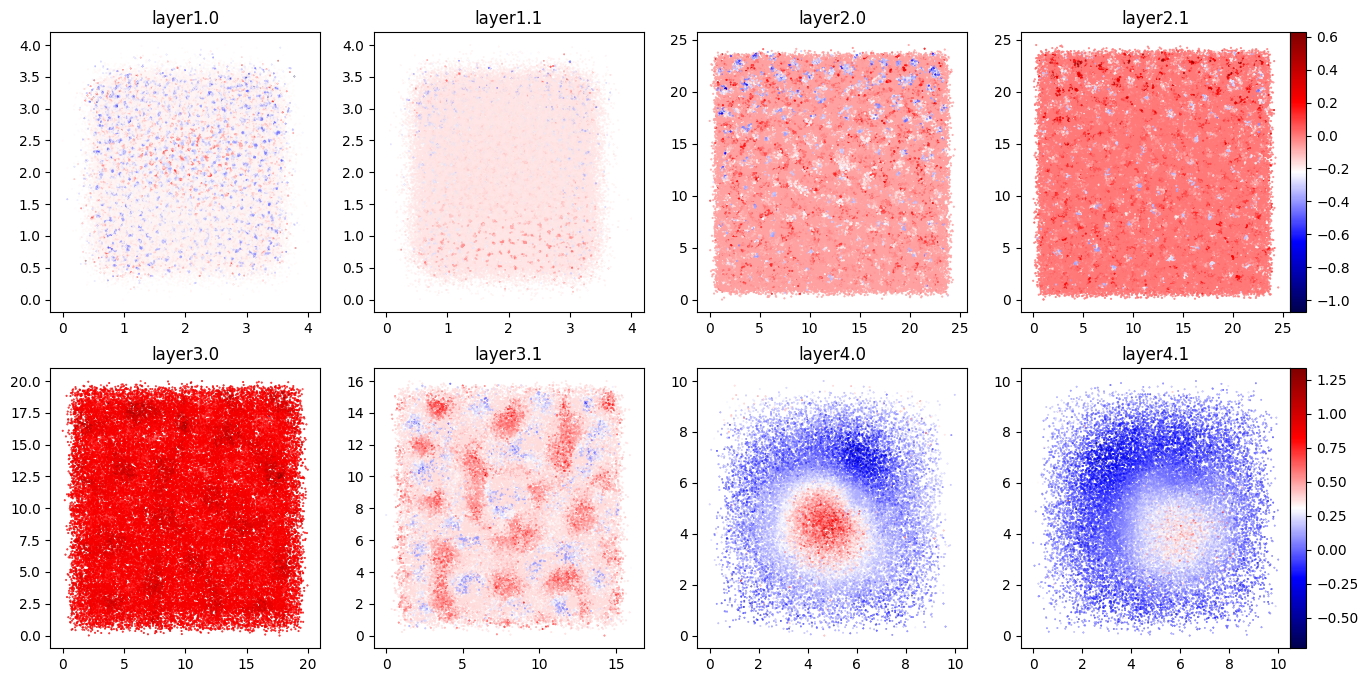

property 2 map


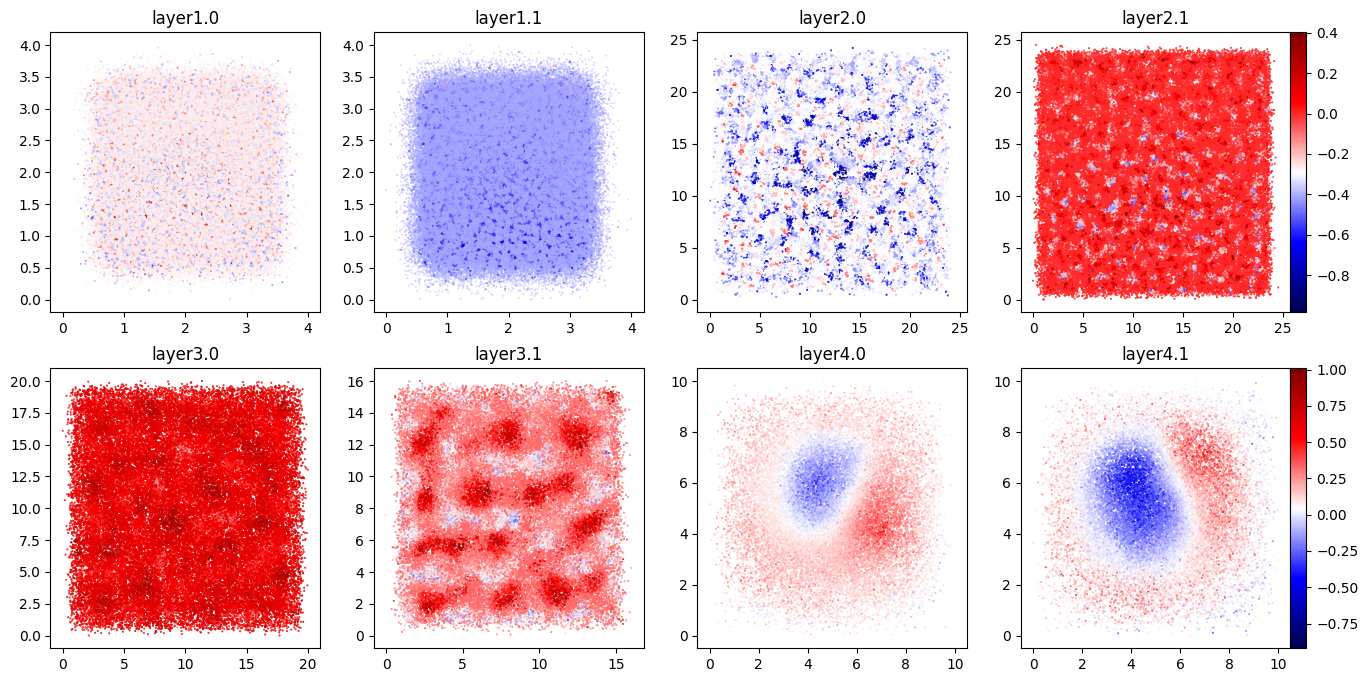

property 3 map


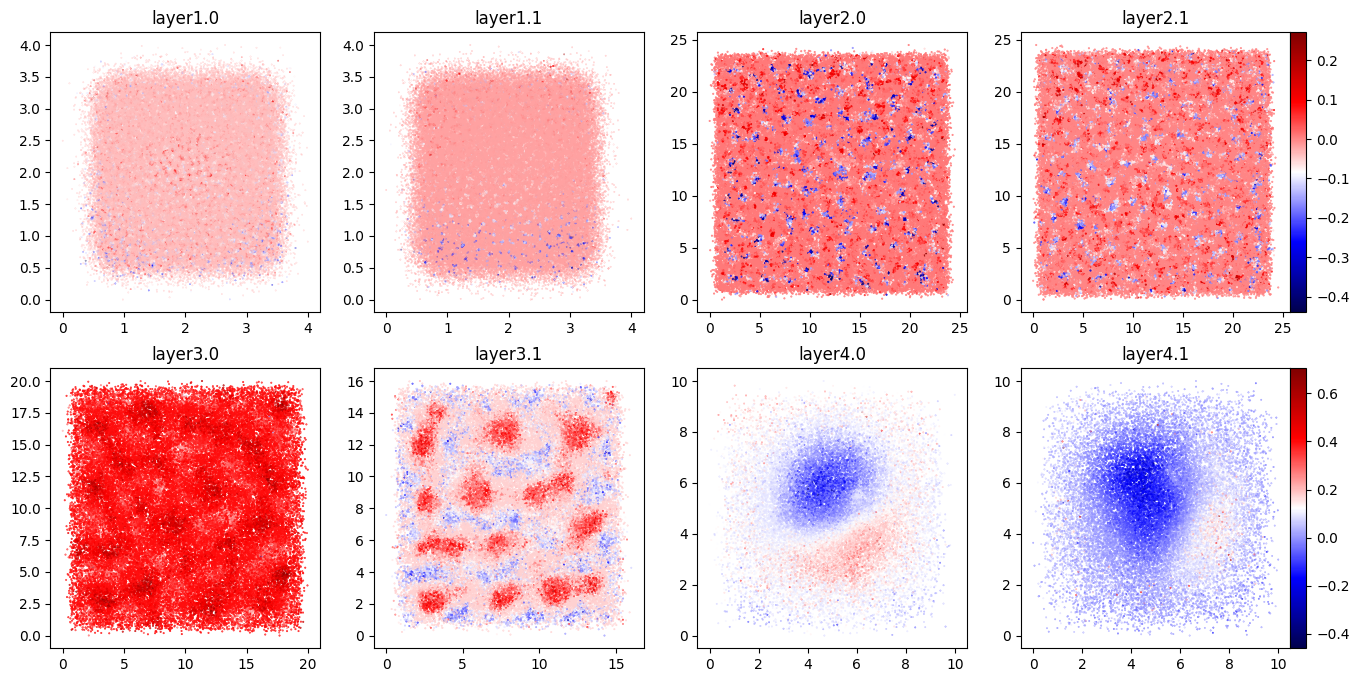

In [81]:
# show sig. pred. prop weight in each layer
import matplotlib.pyplot as plt
import matplotlib.transforms as mtransforms

def add_right_cax(ax, pad, width):
    '''
    在一个ax右边追加与之等高的cax.
    pad是cax与ax的间距,width是cax的宽度.
    '''
    axpos = ax.get_position()
    caxpos = mtransforms.Bbox.from_extents(
        axpos.x1 + pad,
        axpos.y0,
        axpos.x1 + pad + width,
        axpos.y1
    )
    cax = ax.figure.add_axes(caxpos)

    return cax

# load positions from each model layer
network_positions = NetworkPositions.load_from_dir(positions_dir)

for i in range(3):
    fig, axes = plt.subplots(
        nrows=2,
        ncols=4,
        figsize=(16, 8)
    )
    print('property %d map' % (i+1))
    for ax, layer in zip(axes.ravel(), LAYERS):
        # coordinates is an N x 2 matrix of unit positions, in mm
        coordinates = network_positions.layer_positions[layer].coordinates
        
        # responses is an N-dimensional response vector from each layer
        responses = md_wei[layer][:,i]
        responses_ = np.multiply(responses, ly_mask[layer])
        # plot points, scaling by total size of the tissue in each layer
        extent = np.ptp(coordinates)
        
        ax_ = ax.scatter(*coordinates.T, c=responses_, cmap='seismic', s=extent / 100)
        ax.set_title(layer)
        # ax.set_xticks([])
        # ax.set_yticks([])
        if layer==lys[7] or layer==lys[3]:
            cax = add_right_cax(ax, pad=0, width=0.01)
            fig.colorbar(ax_, cax=cax)
    plt.show()




In [3]:
# trial6 PLSR between model and brain
# so could get bra clu voxel wei to each mdl unit

# prepare brain data
import os
import h5py
import numpy as np
import scipy.io as scio
import matplotlib.pyplot as plt
from os.path import join as pjoin
# from nilearn.masking import apply_mask, unmask

basedir = r'/n02dat01/users/qdzhao/THINGS'
sub = '01'

outdir_ = pjoin(basedir, r'property_analysis/derivatives/2_pro_relation')
ind = scio.loadmat(pjoin(outdir_, f'index_1854to720.mat'))
ind_1854to720 = ind['index_1854to720'][0].squeeze().tolist()

f_dir = pjoin(basedir, r'property_analysis/derivatives/linear_model','sub-'+sub)
# p value of training set
adjp_f = pjoin(f_dir, 'prop_pcs', f'cross_validation_permutation_result.mat')
adjp = h5py.File(adjp_f)
print(adjp.keys())
adjp_ = adjp['adj_p']
adj_p = np.squeeze(adjp_)

cor_f = pjoin(f_dir, 'prop_pcs', f'model_test_result.mat')
corf = h5py.File(cor_f)
print(corf.keys())
cor_ = corf['R']
cor = np.squeeze(cor_) # r value

# # prop pcs selection of each voxel in each ROI
# wei_f = pjoin(f_dir, 'prop_pcs','encoding_training_result.mat')
# weif = h5py.File(wei_f) # encoding weight
# print(weif.keys())
# wei_ = weif['thetaFinal']
# wei = np.squeeze(wei_)
# print(wei.shape) #(V,5)

mkb = [] # sig mask of brain
for j in range(len(adj_p)):
    if adj_p[j]<0.05 and cor[j]>0.05:
        mkb.append(j)
# wei_s = wei[mkb,:3]

# prop selection in each cluster

yhat_ = np.load(pjoin(f_dir,'prop_pcs','volume_pc_clu_label3.npz'))
yhat = yhat_['label']

idxb_clu1 = [] # idx of brain for each clu
idxb_clu2 = []
idxb_clu3 = []

for i in range(len(mkb)):
    if yhat[i] == 0:
        idxb_clu1.append(i)
    if yhat[i] == 1:
        idxb_clu2.append(i)
    if yhat[i] == 2:
        idxb_clu3.append(i)

# weib_clu1 = wei_s[idxb_clu1] # (1904,3)
# weib_clu2 = wei_s[idxb_clu2] # (1055,3)
# weib_clu3 = wei_s[idxb_clu3] # (1551,3)

# prepare brain activation
betas_csv_dir = pjoin(basedir, r'THINGS_fMRI/betas_csv')
betas_concept_ = scio.loadmat(pjoin(betas_csv_dir, f'sub-{sub}_betas_concept.mat'))
betas_concept =  betas_concept_['data'] # (V,720)
print(betas_concept.shape)
                              
# actb_clu1 = betas_concept[mkb][idxb_clu1].T
# # print(act_clu1.shape) # (720,1904)
# actb_clu2 = betas_concept[mkb][idxb_clu2].T
# # print(act_clu2.shape) # (720,1055)
# actb_clu3 = betas_concept[mkb][idxb_clu3].T
# # print(act_clu3.shape) # # (720,1551)
# # act_clu = [act_clu1,act_clu2,act_clu3]

# prepare model activation
img_fea_dir = pjoin(basedir, r'THINGS_stimuli/THINGS/derivatives/dnn_feature_maps/TDANN')
img_partitions = os.listdir(img_fea_dir)
img_partitions.sort()
img_fea = []
for p in img_partitions:
    part_dir = os.path.join(img_fea_dir, p)
    fea = np.load(part_dir,allow_pickle=True)
    fea_ = fea.tolist()
    img_fea.append(fea_[lys[7]].flatten())
#     img_fea.append(fea_['fc8'])
img_model_ = np.array(img_fea)
#     img_alex = img_fea_[obj12_df.index]
img_model_sub = img_model_[ind_1854to720]
print(img_model_sub.shape) #(720,25088)
img_model_sub = img_model_sub
# actm_clu1 = img_model_sub[mk][idx_clu1].T # model activation for each clu
# actm_clu2 = img_model_sub[mk][idx_clu2].T
# actm_clu3 = img_model_sub[mk][idx_clu3].T

<KeysViewHDF5 ['adj_p', 'mask', 'trial_sum_all']>
<KeysViewHDF5 ['R', 'X_pred', 'betas_test']>
(720, 211339)
(720, 25088)


In [4]:
from sklearn.cross_decomposition import PLSRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from scipy.stats import pearsonr

print(betas_concept.T[mkb].shape) #(4510, 720)
print(img_model_sub.shape) #(25088, 720)
x = betas_concept.T[mkb].T
y = img_model_sub
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.1, random_state=97)


(4510, 720)
(720, 25088)


0.7107723187231337 0.1393916548220178
0.9189809904098111 0.21830678946680937


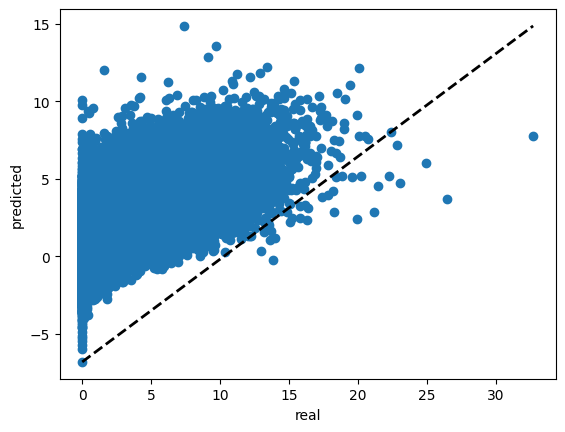

In [7]:
# plsregression
plsr = PLSRegression(n_components=50)
plsr.fit(x_train,y_train)

y_pred = plsr.predict(x_test)

# score = plsr.score(x_test,y_test) # score is 1, best
# print(score)
cor = []
for i in range(y_test.shape[0]):
    cor_ = pearsonr(y_pred[i],y_test[i])
    cor.append(cor_[0])
cor_mean = np.mean(np.array(cor))
cor_std = np.std(np.array(cor))
print(cor_mean, cor_std)
print(np.max(cor),np.min(cor))

plt.scatter(y_test,y_pred)
plt.xlabel('real')
plt.ylabel('predicted')
plt.plot([y_test.min(),y_test.max()],[y_pred.min(),y_pred.max()],'k--',lw=2)
plt.show()


0.7096940610518133


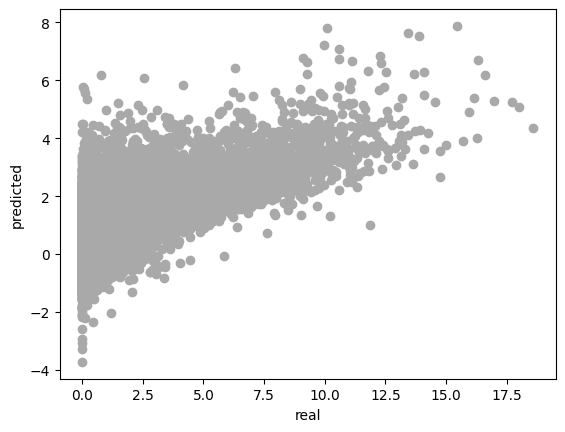

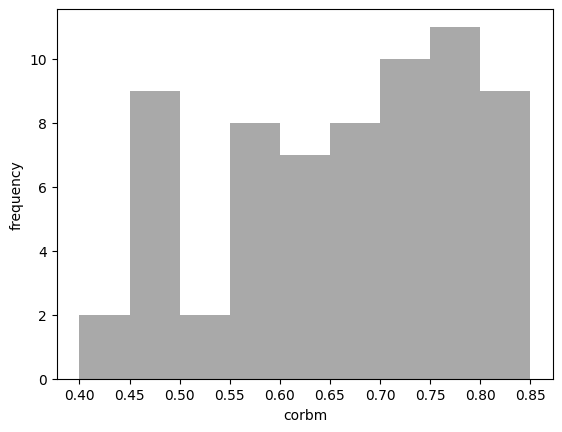

In [36]:
IDX = 1
plt.scatter(y_test[IDX],y_pred[IDX],c='darkgrey')
print(np.array(cor)[IDX])
plt.xlabel('real')
plt.ylabel('predicted')
# plt.plot([y_test.min(),y_test.max()],[y_pred.min(),y_pred.max()],'k--',lw=2)
plt.show()

# histogram of correlation in test set
d = 0.05
num_bin = np.arange(0.4,0.9,d)
#print(max(a)-min(a),max(a),min(a))

# plt.figure(figsize=(16,6),dpi=80)
plt.hist(np.array(cor), num_bin,color='darkgrey')
plt.xticks(num_bin)
plt.xlabel('corbm')
plt.ylabel('frequency')
#     plt.title('property histogram',size=15)
#     plt.grid(alpha=0.4)
plt.show()

[0.69       0.63666667 0.51666667 0.52       0.42333333]
[0.02828427 0.01885618 0.01247219 0.00816497 0.01699673]


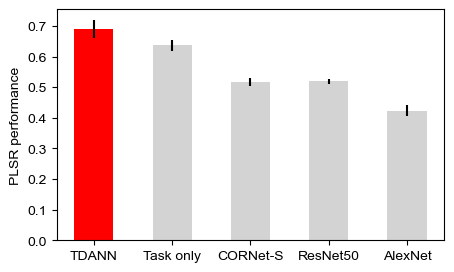

In [2]:
# tdann vs alexnet on plsr performance across 3 subs
import numpy as np
import matplotlib.pyplot as plt

tdan_perf = np.array([0.71,0.71,0.65])
taskonly_perf = np.array([ 0.65, 0.65, 0.61])
alex_perf = np.array([0.44,0.43,0.40])
corn_perf = np.array([0.53,0.52,0.50]) # cornet-s
resn_perf = np.array([0.53,0.52,0.51]) # resnet50
perf = np.array([tdan_perf,taskonly_perf,corn_perf,resn_perf,alex_perf])

mean_perf = np.mean(perf, axis=1)
print(mean_perf)
std_perf = np.std(perf, axis=1)
print(std_perf)


x = np.arange(5)
xlb = ['TDANN', 'Task only', 'CORNet-S', 'ResNet50', 'AlexNet']
cor = ['red','lightgray','lightgray','lightgray','lightgray']
width = 0.5

plt.figure(figsize=(5,3)) # ,dpi=300
plt.rc('font',family='Arial', size=10)

plt.bar(x,mean_perf,width=width,yerr=std_perf,color=cor)

font_dict = {'family':'Arial', 'size':10}
plt.xticks(x,labels=xlb,fontproperties=font_dict) # 
# plt.xlabel('Cluster',fontdict=font_dict)
plt.ylabel('PLSR performance',fontdict=font_dict)
# plt.legend(loc='best',prop=font_dict)
# plt.title('ROI prop selection') 
plt.show()
plt.close()

In [27]:
print(plsr.x_weights_.shape)
print(plsr.y_weights_.shape)
print(plsr.x_rotations_.shape)
print(plsr.y_rotations_.shape)

(4510, 50)
(25088, 50)
(4510, 50)
(25088, 50)


In [32]:
# y_pred = plsr.predict(x_test[:1])
# y_pred_1 = np.dot(x,plsr.coef_.T)+plsr.intercept_
# y_pred_2 = np.dot(np.dot(x_test[0],plsr.x_weights_),plsr.y_weights_.T)
# y_pred_3 = np.dot(np.dot(x_test[0],plsr.x_rotations_),plsr.y_rotations_.T)
# dif = y_pred[0]-y_pred_
# print(np.max(dif),np.min(dif))
# cor = pearsonr(y_test[0],y_pred_1)
# print(cor[0])
# cor = pearsonr(y_pred[0],y_pred_1)
# print(cor[0])
# cor = pearsonr(y_pred[0],y_pred_2)
# print(cor[0])
# cor = pearsonr(y_pred[0],y_pred_3)
# print(cor[0])
# dif = plsr.coef_ - np.dot(plsr.y_rotations_,plsr.x_rotations_.T)
# print(np.max(dif),np.min(dif))

y_pred = plsr.predict(x_test)
print()
x_mean = np.mean(x_train,axis=0)
x = x_test - x_mean # centerize

y_pred_ = np.dot(x,plsr.coef_.T) #+plsr.intercept_
cor = []
for i in range(y_test.shape[0]):
    cor_ = pearsonr(y_pred_[i],y_pred[i])
    cor.append(cor_[0])
cor_mean = np.mean(np.array(cor))
cor_std = np.std(np.array(cor))
print(cor_mean, cor_std)
print(np.max(cor),np.min(cor))


0.7922439608404966 0.09412307795034242
0.9250595034029858 0.5164636725831641


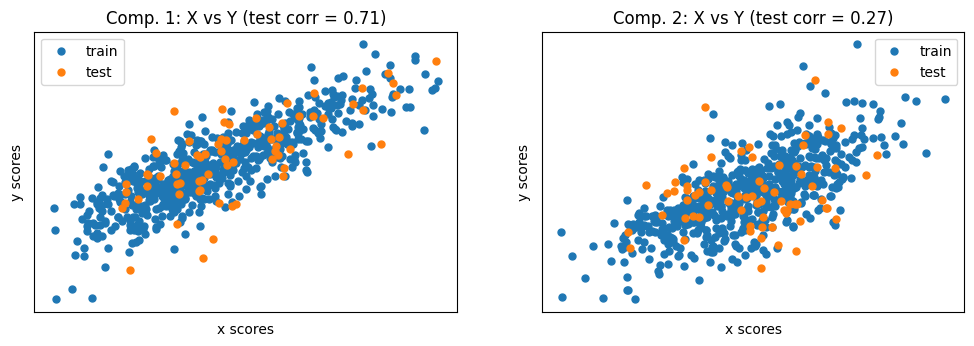

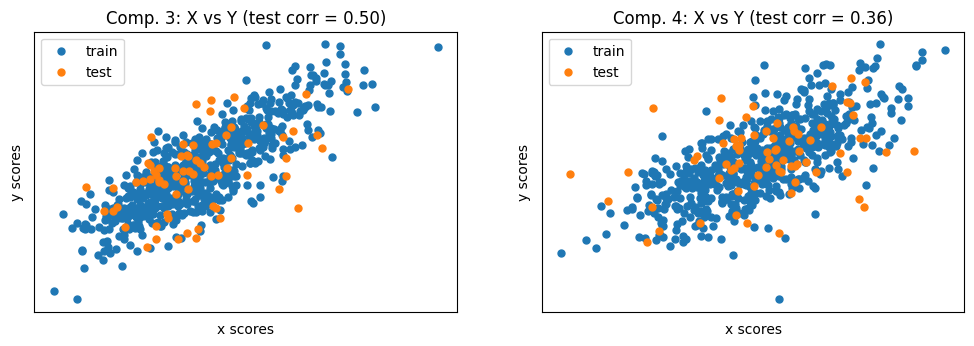

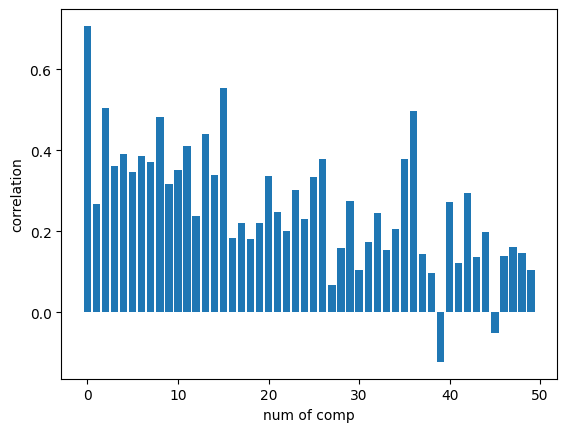

In [9]:
x_trc, y_trc = plsr.transform(x_train, y_train)
x_tec, y_tec = plsr.transform(x_test,y_test) #(72,50),(72,50)

# On diagonal plot X vs Y scores on each components
plt.figure(figsize=(12, 8))
plt.subplot(221)
plt.scatter(x_trc[:, 0], y_trc[:, 0], label="train", marker="o", s=25)
plt.scatter(x_tec[:, 0], y_tec[:, 0], label="test", marker="o", s=25)
plt.xlabel("x scores")
plt.ylabel("y scores")
plt.title(
    "Comp. 1: X vs Y (test corr = %.2f)"
    % np.corrcoef(x_tec[:, 0], y_tec[:, 0])[0, 1]
)
plt.xticks(())
plt.yticks(())
plt.legend(loc="best")

plt.subplot(222)
plt.scatter(x_trc[:, 1], y_trc[:, 1], label="train", marker="o", s=25)
plt.scatter(x_tec[:, 1], y_tec[:, 1], label="test", marker="o", s=25)
plt.xlabel("x scores")
plt.ylabel("y scores")
plt.title(
    "Comp. 2: X vs Y (test corr = %.2f)"
    % np.corrcoef(x_tec[:, 1], y_tec[:, 1])[0, 1]
)
plt.xticks(())
plt.yticks(())
plt.legend(loc="best")

# On diagonal plot X vs Y scores on each components
plt.figure(figsize=(12, 8))
plt.subplot(223)
plt.scatter(x_trc[:, 2], y_trc[:, 2], label="train", marker="o", s=25)
plt.scatter(x_tec[:, 2], y_tec[:, 2], label="test", marker="o", s=25)
plt.xlabel("x scores")
plt.ylabel("y scores")
plt.title(
    "Comp. 3: X vs Y (test corr = %.2f)"
    % np.corrcoef(x_tec[:, 2], y_tec[:, 2])[0, 1]
)
plt.xticks(())
plt.yticks(())
plt.legend(loc="best")

plt.subplot(224)
plt.scatter(x_trc[:, 3], y_trc[:, 3], label="train", marker="o", s=25)
plt.scatter(x_tec[:, 3], y_tec[:, 3], label="test", marker="o", s=25)
plt.xlabel("x scores")
plt.ylabel("y scores")
plt.title(
    "Comp. 4: X vs Y (test corr = %.2f)"
    % np.corrcoef(x_tec[:, 3], y_tec[:, 3])[0, 1]
)
plt.xticks(())
plt.yticks(())
plt.legend(loc="best")
plt.show()

corc = []
for i in range(50):
    cor = np.corrcoef(x_tec[:,i],y_tec[:,i])
    corc.append(cor[0,1])
x = np.arange(50)
y = np.array(corc)
plt.bar(x,y)
plt.xlabel('num of comp')
plt.ylabel('correlation')
plt.show()

(25088, 4510)


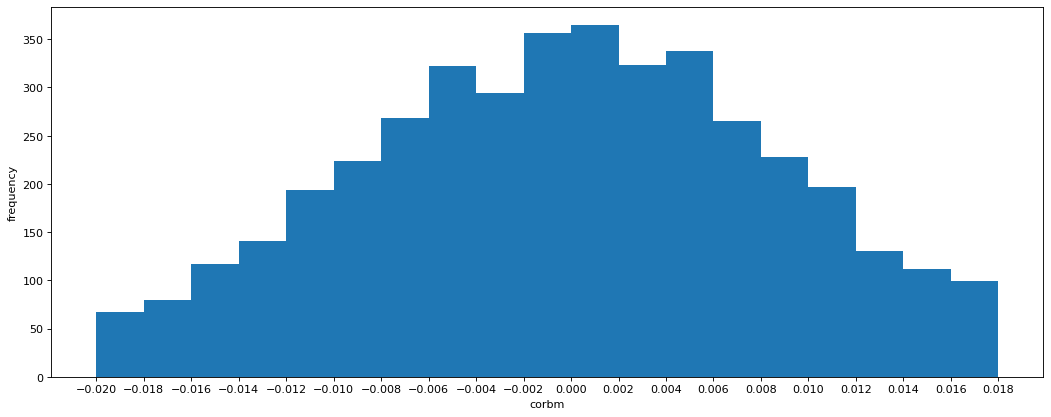

In [71]:
mrx = plsr.coef_
print(mrx.shape) # (U,V)

d = 0.002
num_bin = np.arange(-0.02,0.02,d)
#print(max(a)-min(a),max(a),min(a))

plt.figure(figsize=(16,6),dpi=80)
IDX = 1500
plt.hist(mrx[IDX,:], num_bin)
plt.xticks(num_bin)
plt.xlabel('corbm')
plt.ylabel('frequency')
#     plt.title('property histogram',size=15)
#     plt.grid(alpha=0.4)
plt.show()

(25088, 4510)
-7.805614966557453e-05 -9.893855166841705e-05 0.00029857067162300646


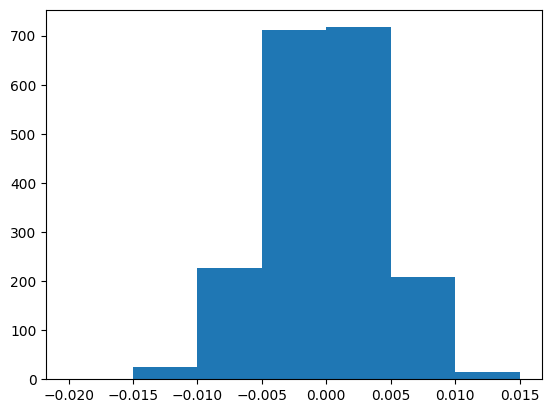

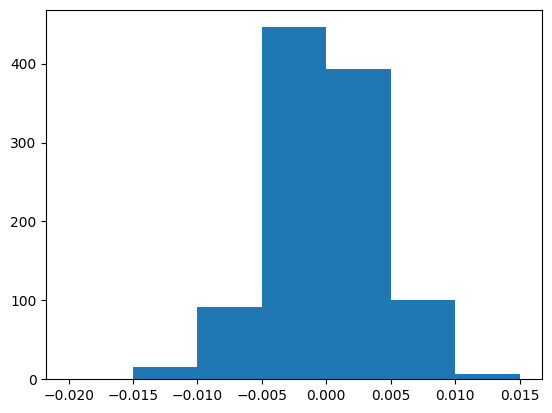

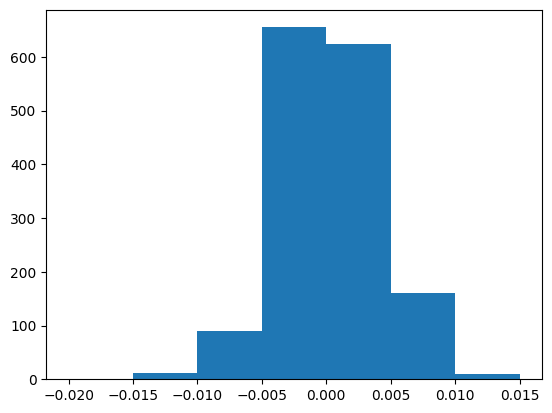

In [ ]:
mrx = plsr.coef_
print(mrx.shape) # (U,V)

mrx_1 = mrx.T[idxb_clu1]
# mrx_1_vot = np.sum(mrx_1,axis=0)
mrx_2 = mrx.T[idxb_clu2]
mrx_3 = mrx.T[idxb_clu3]

d = 0.005
num_bin = np.arange(-0.02,0.02,d)
#print(max(a)-min(a),max(a),min(a))

plt.figure() # figsize=(16,6),dpi=80

IDX = idxm_clu3[1000]
print(np.mean(mrx_1[:,IDX]),np.mean(mrx_2[:,IDX]),np.mean(mrx_3[:,IDX]))

plt.hist(mrx_1[:,IDX], num_bin)
plt.xticks(num_bin)
plt.show()

plt.hist(mrx_2[:,IDX], num_bin)
plt.xticks(num_bin)
plt.show()

plt.hist(mrx_3[:,IDX], num_bin)
plt.xticks(num_bin)
plt.show()



In [8]:
# def clu lab to each unit
def cmp(x):
    lb = np.array([0,1,2])
    st = np.argsort(-x)
    lb = lb[st]
    x = x[st]
    dif1 = x[0]-x[1] # slope of dif1 bigger than dif2
    dif2 = x[1]-x[2]
    if x[0]>0 and dif1>=dif2:
        return lb[0],x[0]
    else:
        return -1,0

mrx = plsr.coef_
print(mrx.shape)
# nm = lys[7]+'_bra_plsr_wei.npz'
# np.savez(pjoin(fdir, lys[j], nm),data = mrx)

mrx_1 = mrx.T[idxb_clu1]
mrx_1_vot = np.mean(mrx_1,axis=0)
mrx_2 = mrx.T[idxb_clu2]
mrx_2_vot = np.mean(mrx_2,axis=0)
mrx_3 = mrx.T[idxb_clu3]
mrx_3_vot = np.mean(mrx_3,axis=0)

bclum_lb = [] # unit label correpsonding to bra clu
bclum_vl = [] # unit value according to plsr.wei
for i in range(mrx.shape[0]):
    x = np.array([mrx_1_vot[i],mrx_2_vot[i],mrx_3_vot[i]])
    a,b = cmp(x)
    bclum_lb.append(a)
    bclum_vl.append(b)

# nm = lys[7]+'_b2m_thr_plsr_label3.npz'
# np.savez(pjoin(fdir, lys[j], nm),label = bclum_lb)


(25088, 4510)


In [ ]:
# print(np.max(mrx),np.min(mrx))
# print(len(idxb))
# print(len(idxb_clu1))
# print(len(idxb_clu2))
# print(len(idxb_clu3))
# print(img_model_sub.shape)
# print(len(idxm_clu1))
# print(len(idxm_clu2))
# print(len(idxm_clu3))
# print(len(idxm_clux))
# print(len(idxm_clu1)+len(idxm_clu2)+len(idxm_clu3)+len(idxm_clux))
# print(mrx__.shape)

/share/home/qdzhao/.local/lib/python3.8/site-packages/pandas/core/computation/expressions.py:21: UserWarning: Pandas requires version '2.7.3' or newer of 'numexpr' (version '2.7.2' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


(25088, 4510)
(4510, 19447)


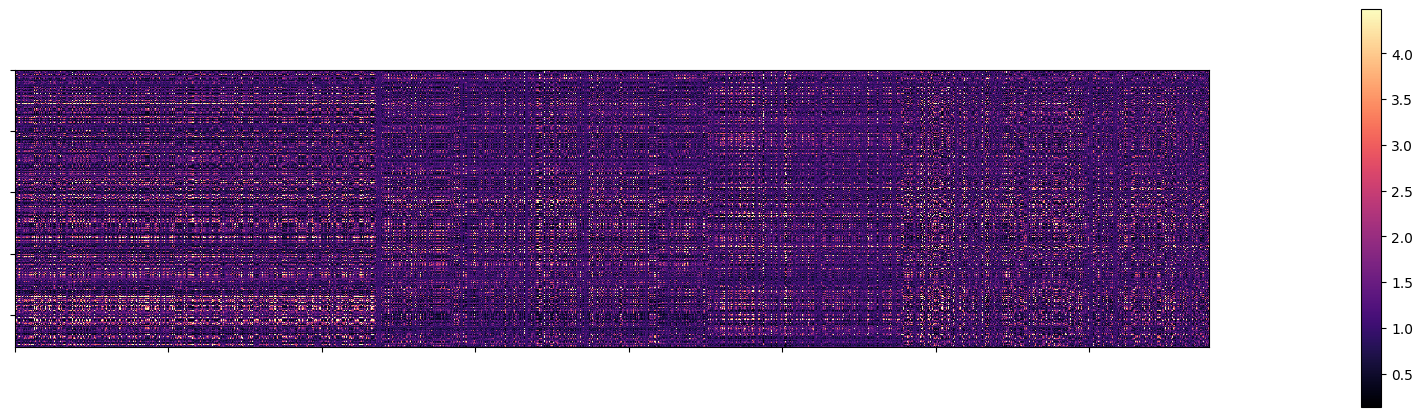

In [9]:
from nilearn import plotting

mrx = plsr.coef_
print(mrx.shape)

idxb = idxb_clu3+idxb_clu1+idxb_clu2

# j = 7
# nm = lys[j]+'_b2m_thr_clu_label3.npz'
# yhat_ = np.load(pjoin(fdir, lys[j], nm))
# yhat = yhat_['label']
# bclum_lb_ = np.zeros(img_model_sub.shape[1])-1
# bclum_lb_[mk] = np.array(yhat)
idxm_clu1 = []
idxm_clu2 = []
idxm_clu3 = []
idxm_clux = []
for i in range(img_model_sub.shape[1]):
    if bclum_lb[i]==0:
        idxm_clu1.append(i)
    elif bclum_lb[i]==1:
        idxm_clu2.append(i)
    elif bclum_lb[i]==2:
        idxm_clu3.append(i)
    else:
        idxm_clux.append(i)
idxm = idxm_clu2+idxm_clu1+idxm_clu3+idxm_clux[:5000]

mrx_ = mrx[idxm]
mrx__ = mrx_.T[idxb]
print(mrx__.shape)
fig = plt.figure(figsize=(15,5))
plotting.plot_matrix(np.exp(mrx__*100),colorbar=True,cmap='magma',vmax=np.exp(0.015*100),vmin=np.exp(-0.02*100),figure = fig) # 
# plotting.show()
plt.show()


(25088, 4510)


(4510, 19447)


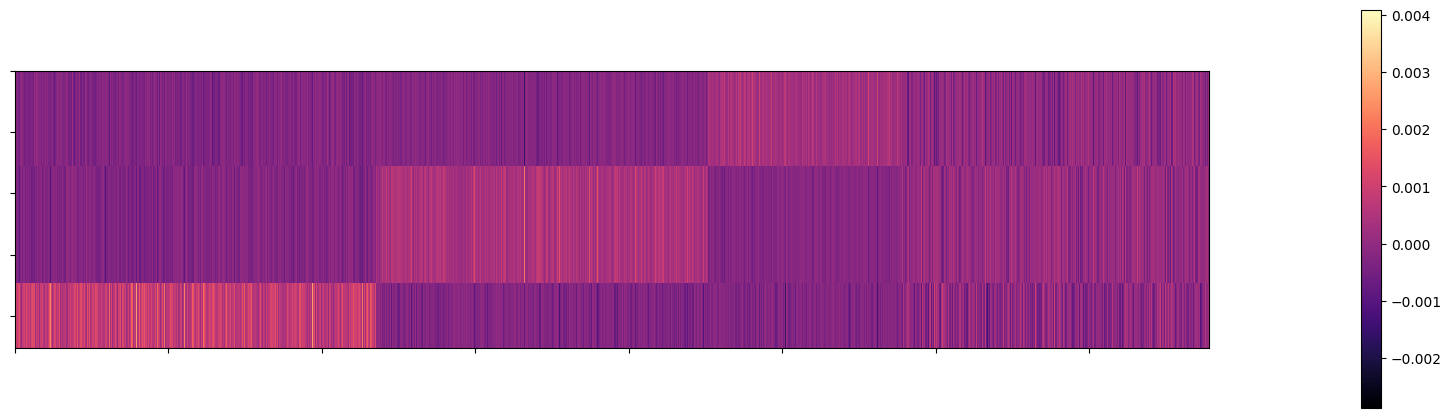

In [10]:
mrx = plsr.coef_
print(mrx.shape) # (u,v)

mrx_ = mrx[idxm] # 
mrx_1 = np.mean(mrx_.T[idxb_clu1],axis=0) #(u_,)
mrx_1_rep = np.tile(mrx_1,len(idxb_clu1)).reshape(-1,mrx_1.shape[0]) # (v_,u_)
mrx_2 = np.mean(mrx_.T[idxb_clu2],axis=0)
mrx_2_rep = np.tile(mrx_2,len(idxb_clu2)).reshape(-1,mrx_2.shape[0]) # (v_,u_)
mrx_3 = np.mean(mrx_.T[idxb_clu3],axis=0)
mrx_3_rep = np.tile(mrx_3,len(idxb_clu3)).reshape(-1,mrx_3.shape[0]) # (v_,u_)
mrx__ = np.append(mrx_3_rep,mrx_1_rep,axis=0)
mrx__ = np.append(mrx__,mrx_2_rep,axis=0)
print(mrx__.shape)

fig = plt.figure(figsize=(15,5))
plotting.plot_matrix(mrx__,colorbar=True,cmap='magma',figure = fig) # 
# plotting.show()
plt.show()


findfont: Font family ['Arial'] not found. Falling back to DejaVu Sans.


[[ 126.41939326 -238.57669251 -107.88443569]
 [ 121.66495716  150.2411179    64.56241339]
 [-157.15142032  -10.39050235  -14.45444844]]


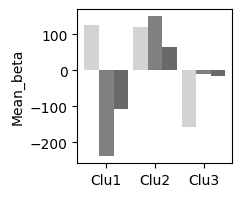

In [13]:
# prop pattern
import matplotlib.pyplot as plt

clu1 = md_wei[lys[7]][idxm_clu1,:3]
clu2 = md_wei[lys[7]][idxm_clu2,:3]
clu3 = md_wei[lys[7]][idxm_clu3,:3]

wei_clu1_col = np.mean(clu1,axis=0)*1000 # (3,)
wei_clu2_col = np.mean(clu2,axis=0)*1000
wei_clu3_col = np.mean(clu3,axis=0)*1000

wei_clu_col = [] 
wei_clu_col.append(wei_clu2_col)
wei_clu_col.append(wei_clu1_col)
wei_clu_col.append(wei_clu3_col)
wei_clu_col = np.array(wei_clu_col)
print(wei_clu_col)
# [[ 237.49099968   52.97494511   41.23299597]
#  [  34.70398187 -260.01369762 -109.16882459]
#  [ -58.46024717  128.67514709   20.96782858]]

xlb = ['Clu1', 'Clu2', 'Clu3']
x = np.arange(len(xlb))
width = 0.3
ly2 = x - width
ly3 = x
ly4 = x + width

plt.figure(figsize=(2,2)) # ,dpi=300
plt.rc('font',family='Arial', size=10)
plt.bar(ly2,wei_clu_col.T[0],width=width,color='lightgrey',label='PC1') # "orange" "cyan" "mediumpurple"
plt.bar(ly3,wei_clu_col.T[1],width=width,color='grey',label='PC2')
plt.bar(ly4,wei_clu_col.T[2],width=width,color='dimgrey',label='PC3')

font_dict = {'family':'Arial', 'size':10}
plt.xticks(x,labels=xlb,fontproperties=font_dict)
# plt.xlabel('Cluster',fontdict=font_dict)
plt.ylabel('Mean_beta',fontdict=font_dict)
# plt.legend(loc='best',prop=font_dict)
# plt.title('ROI prop selection')
plt.show()
plt.close()


In [48]:
from matplotlib import colors 

N = 256 #(0-255)
rgb = colors.to_rgb('hotpink')
print(N*np.array(rgb)) # (255,104,180)
rgb = colors.to_rgb('darkgreen')
print(N*np.array(rgb)) # (0,99,0)
rgb = colors.to_rgb('steelblue')
print(N*np.array(rgb)) # (69,130,180)


[256.         105.41176471 180.70588235]
[  0.         100.39215686   0.        ]
[ 70.2745098  130.50980392 180.70588235]


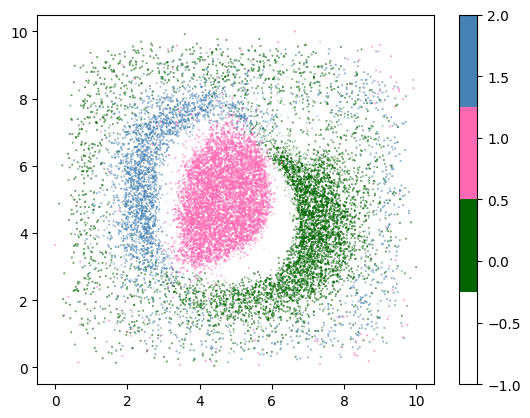

(25088, 4510)
[1.43315532 5.28710512]


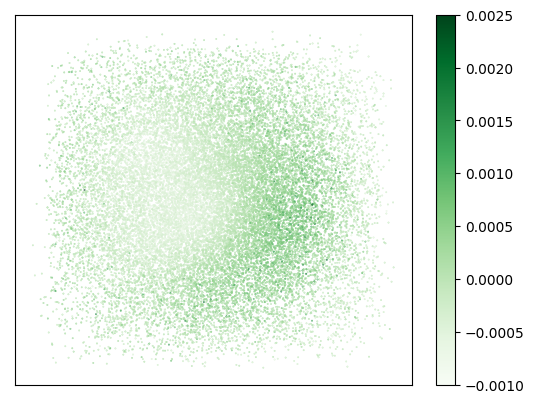

(1.0, 0.4117647058823529, 0.7058823529411765)
[4.80164207 5.31460736]


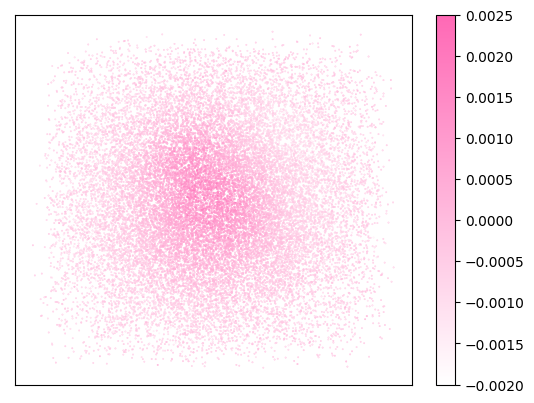

[7.12043781 7.11021841]


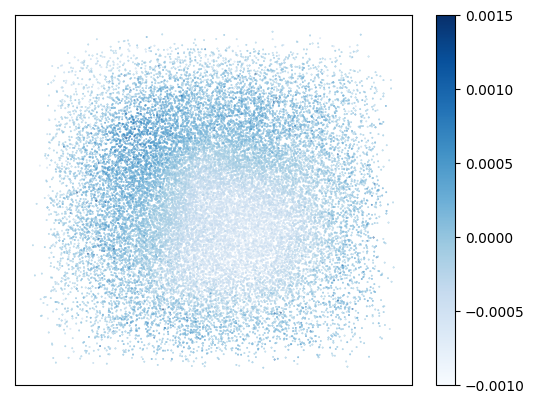

In [27]:
# map visualization 
# each clu simulated map
# show sig. pred. prop weight in each layer
import matplotlib.pyplot as plt
from matplotlib import colors 
from matplotlib.colors import ListedColormap,LinearSegmentedColormap


# load positions from each model layer
network_positions = NetworkPositions.load_from_dir(positions_dir)

fig = plt.figure() 
# coordinates is an N x 2 matrix of unit positions, in mm
layer = lys[7]
coordinates = network_positions.layer_positions[layer].coordinates
# responses is an N-dimensional response vector from each layer
responses_ = bclum_lb
# plot points, scaling by total size of the tissue in each layer
extent = np.ptp(coordinates)
# cmap_ = ListedColormap(["white", "hotpink", "steelblue", "darkgreen"]) # (1,3,2)
cmap_ = ListedColormap(["white", "darkgreen", "hotpink", "steelblue"]) # (2,1,3)
plt.scatter(*coordinates.T, c=responses_, cmap=cmap_, s=extent/100)
plt.colorbar()
# plt.xticks([])
# plt.yticks([])
plt.show()

# bclum_lb_1 = np.zeros(img_model_sub.shape[1])-1
# bclum_lb_1[idxm_clu1] = 0
# print(len(idxm_clu1))
# bclum_lb_2 = np.zeros(img_model_sub.shape[1])-1
# bclum_lb_2[idxm_clu2] = 1
# print(len(idxm_clu2))
# bclum_lb_3 = np.zeros(img_model_sub.shape[1])-1
# bclum_lb_3[idxm_clu3] = 2
# print(len(idxm_clu3))

# bclum_lb_1 = np.array(bclum_vl)+0 # actually should be bclum_vl_1/2/3
# bclum_lb_1[idxm_clu2+idxm_clu3] = 0
# print(len(idxm_clu1))
# bclum_lb_2 = np.array(bclum_vl)+0
# bclum_lb_2[idxm_clu1+idxm_clu3] = 0
# print(len(idxm_clu2))
# bclum_lb_3 = np.array(bclum_vl)+0
# bclum_lb_3[idxm_clu2+idxm_clu1] = 0
# print(len(idxm_clu3))

# mrx_ = plsr.coef_
mrx_ = wei
print(mrx_.shape) # (u,v)
# idxm_ = idxm_clu2+idxm_clu1+idxm_clu3+idxm_clux
# mrx_ = mrx[idxm_] # 
mrx_1 = np.mean(mrx_.T[idxb_clu1],axis=0) #(u_,)
mrx_2 = np.mean(mrx_.T[idxb_clu2],axis=0)
mrx_3 = np.mean(mrx_.T[idxb_clu3],axis=0)

# clu1
responses_ = mrx_1 # mean value of unit weights belong to bra clu1
maxid = np.argmax(responses_)
print(coordinates[maxid].T)
# plot points, scaling by total size of the tissue in each layer
extent = np.ptp(coordinates)
# cmap_ = ListedColormap(["white", "darkgreen"])
plt.scatter(*coordinates.T, c=responses_, cmap='Greens', s=extent/100, vmax=0.0025,vmin=-0.0010)
plt.colorbar()
plt.xticks([])
plt.yticks([])
plt.show()

# clu2
rgb = colors.to_rgb('hotpink')
print(rgb) # (1.0, 0.4117647058823529, 0.7058823529411765)
N = 256
vals = np.ones((N, 4))
vals[:, 0] = np.linspace(1.00, 1, N)
vals[:, 1] = np.linspace(0.41, 1, N)
vals[:, 2] = np.linspace(0.71, 1, N)
cmp = ListedColormap(vals).reversed()

responses_ = mrx_2
maxid = np.argmax(responses_)
print(coordinates[maxid].T)
# plot points, scaling by total size of the tissue in each layer
extent = np.ptp(coordinates)
plt.scatter(*coordinates.T, c=responses_, cmap=cmp, s=extent/100,vmax=0.0025,vmin=-0.0020)
plt.colorbar()
plt.xticks([])
plt.yticks([])
plt.show()

# clu3
responses_ = mrx_3
maxid = np.argmax(responses_)
print(coordinates[maxid].T)
# plot points, scaling by total size of the tissue in each layer
extent = np.ptp(coordinates)
# cmap_ = ListedColormap(["white", "steelblue"])
plt.scatter(*coordinates.T, c=responses_, cmap='Blues', s=extent/100, vmax=0.0015,vmin=-0.0010)
plt.colorbar()
plt.xticks([])
plt.yticks([])
plt.show()




In [13]:
print(np.max(mrx_1),np.min(mrx_1))
print(np.max(mrx_2),np.min(mrx_2))
print(np.max(mrx_3),np.min(mrx_3))

0.00408102325527781 -0.001606671367317914
0.0033246080570162196 -0.0024922897831005527
0.0017124390263510115 -0.002872958637629054


In [5]:
# classification analysis
import os
import torch
import pandas as pd
import numpy as np
import scipy.io as scio
from os.path import join as pjoin
from sklearn.decomposition import PCA

basedir = r'/n02dat01/users/qdzhao/THINGS'
outdir_ = pjoin(basedir, r'property_analysis/derivatives/2_pro_relation')
ind = scio.loadmat(pjoin(outdir_, f'index_1854to720.mat'))
ind_1854to720 = ind['index_1854to720'][0].squeeze().tolist()

#label
obj_tsv=pjoin(basedir, r'THINGS_stimuli/THINGS',f'things_concepts.tsv')
obj_df = pd.read_csv(obj_tsv, sep='\t')['Word'].tolist()
obj_df_720 = np.array(obj_df)[ind_1854to720].tolist()

lys = ['layer1.0','layer1.1','layer2.0','layer2.1','layer3.0','layer3.1','layer4.0','layer4.1']

# #data
# img_fea_dir = pjoin(basedir, r'property_analysis/derivatives/cnn-som/prop-pcs_tdann/cat_feat')
# img_partitions = os.listdir(img_fea_dir)
# img_partitions.sort()
# img_fea = []
# img_nm = []
# for p in img_partitions:
#     img_nm.append(p.split('.')[0])
#     part_dir = os.path.join(img_fea_dir, p)
#     fea = np.load(part_dir,allow_pickle=True)
#     fea_ = fea.tolist()
#     # img_fea_ = []
#     for id in range(12):
#         img_fea.append(fea_[id]['layer4.1'].squeeze()) # (12,4096)*16
# img_fea_ori = np.array(img_fea)

# print(img_fea_ori.shape) # (216,25088) 216=18*12
# # pca = PCA(n_components=50) #降到 50 维
# # img_fea_ori_50 = pca.fit_transform(img_fea_ori)
# # print(np.sum(pca.explained_variance_ratio_))
# print(img_nm)

# cat1 = ['face','baby','boy','girl','arm','foot','leg','hip']
# cat2 = ['car','bus','piano','phone','pillow','ship']
# cat3 = ['cloud','doghouse','tree','snow']



cat1 = ['watch', 'snake', 'hamster', 'platypus', 'face', 'grasshopper', 'dolphin', 'fish', 'gargoyle', 'kimono']
cat2 = ['lock', 'pliers', 'projector', 'waffle iron', 'mosquito net', 'wrench', 'kite', 'broom', 'washboard', 'game']
cat3 = ['pogo stick', 'pothole', 'hovercraft', 'stalagmite', 'trap', 'railing', 'bench', 'ladder', 'hedge']
img_nm = cat1+cat2+cat3
print(len(img_nm))
target_cats = [['animal',cat1],['object',cat2],['scene',cat3]] # ,['others]
# feature extracted from F:\visual_project\THINGS_project\animacy_analysis\code\model_feature_extraction.ipynb

cats_num = [] # sorted by alphabetas
for j in range(len(img_nm)):
    if img_nm[j] in cat1:
        cats_num.append([0]) # animal
    elif img_nm[j] in cat2:
        cats_num.append([1]) # object
    elif img_nm[j] in cat3:
        cats_num.append([2]) # scene
        # cats_num.append([2]*12) # scene
    # else:
    #     cats_num.append([4]*12)

cats_num = np.array(cats_num)#.flatten()
# print(cats_num.shape) # 21

cat_idx2 = []
for i in range(len(img_nm)):
    cat_idx2.append(obj_df_720.index(img_nm[i]))


/share/home/qdzhao/.local/lib/python3.8/site-packages/pandas/core/computation/expressions.py:21: UserWarning: Pandas requires version '2.7.3' or newer of 'numexpr' (version '2.7.2' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


29


In [7]:
# tri classification algorithm using plsr predited img features
# classifier train
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

#3 prepare plsr weight and idxm_clu
fdir = pjoin(basedir,r'property_analysis/derivatives/cnn-som/prop-pcs_tdann')
id = 7
nm = lys[id]+'_bra_plsr_wei.npz'
wei_ = np.load(pjoin(fdir, lys[id], nm))
wei = wei_['data']
print(wei.shape)

nm = lys[id]+'_b2m_thr_plsr_label3.npz'
bclum_lb_ = np.load(pjoin(fdir, lys[id], nm))
bclum_lb = bclum_lb_['label'] # [0,1,2]
bclum_lb = np.array(bclum_lb)

idxm_clu1 = []
idxm_clu2 = []
idxm_clu3 = []
idxm_clux = []
for i in range(img_model_sub.shape[1]):
    if bclum_lb[i]==0:
        idxm_clu1.append(i)
    elif bclum_lb[i]==1:
        idxm_clu2.append(i)
    elif bclum_lb[i]==2:
        idxm_clu3.append(i)
    else:
        idxm_clux.append(i)

# plsr
# x_train = betas_concept.T[mkb].T
# betas_concept = betas_concept.T
x_mean = np.mean(x_train,axis=0)
x = betas_concept[mkb].T
x = x[cat_idx2]
x = x - x_mean # centerize
print(x.shape) #(n,4510)

# coef = plsr.coef_ + 0
coef = wei + 0
coef[idxm_clux]=0
y_pred = np.dot(x, coef.T)
# y_pred = plsr.predict(x)
# y_pred.T[idxm_clux] = 0

# classifier
X=y_pred
print(X.shape)
Y=cats_num+0

# X = StandardScaler().fit_transform(X)
lr = LogisticRegression()   # Logistic回归模型
lr.fit(X, Y) 

y_hat = lr.predict(X)
Y = Y.reshape(-1)
result = y_hat == Y

id1 = []
id2 = []
id3 = []
for i in range(Y.shape[0]):
    if Y[i] == 0:
        id1.append(i)
    if Y[i] == 1:
        id2.append(i)
    if Y[i] == 2:
        id3.append(i)

acc_ori_1 = np.mean(result[id1])
print('acc_ori_ani: %.2f%%' % (100 * acc_ori_1))
acc_ori_2 = np.mean(result[id2])
print('acc_ori_obj: %.2f%%' % (100 * acc_ori_2))
acc_ori_3 = np.mean(result[id3])
print('acc_ori_sce: %.2f%%' % (100 * acc_ori_3))

acc_ori = np.array([acc_ori_3, acc_ori_1, acc_ori_2])

# x = np.arange(3)
# xlb = ['Sce', 'Ani', 'Obj']
# width = 0.3

# plt.figure(figsize=(2,2)) # ,dpi=300
# plt.rc('font',family='Arial', size=10)

# plt.bar(x,acc_ori,width=width,color="grey") # ,yerr=std_score_bm

# font_dict = {'family':'Arial', 'size':10}
# plt.xticks(x,labels=xlb,fontproperties=font_dict) # 
# # plt.xlabel('Cluster',fontdict=font_dict)
# plt.ylabel('acc',fontdict=font_dict)
# # plt.legend(loc='best',prop=font_dict)
# # plt.title('ROI prop selection') 
# plt.show()
# plt.close()


(25088, 4510)
(29, 4510)
(29, 25088)


/n02dat01/public_resource/anaconda3/lib/python3.8/site-packages/sklearn/utils/validation.py:1183: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


acc_ori_ani: 100.00%
acc_ori_obj: 100.00%
acc_ori_sce: 100.00%


19
(19, 4510)
(19, 25088)
acc_pred_ani: 100.00%
acc_pred_obj: 85.71%
acc_pred_sce: 100.00%
[1.         1.         0.85714286]


findfont: Font family ['Arial'] not found. Falling back to DejaVu Sans.


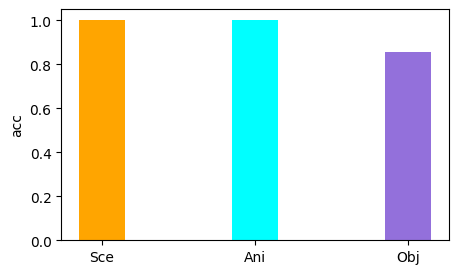

In [28]:
# classification accyracy of y_pred using plsr
# classifier test
import h5py
import pandas as pd
import scipy.io as scio
from os.path import join as pjoin

basedir = r'/n02dat01/users/qdzhao/THINGS'
obj_tsv=pjoin(basedir, r'THINGS_stimuli/THINGS',f'things_concepts.tsv')
obj_df = pd.read_csv(obj_tsv, sep='\t')['Word'].tolist()
obj_df_720 = np.array(obj_df)[ind_1854to720].tolist()

cat1 = ['sloth', 'whale', 'manatee', 'snail', 'girl', 'toucan', 'lobster']
cat2 = ['face mask', 'dustpan', 'pogo stick', 'bracket', 'playing card', 'stair', 'scanner']
cat3 = ['hammock', 'submarine', 'tarp', 'carousel', 'solar panel', ]
img_nm = cat1+cat2+cat3
print(len(img_nm))
target_cats = [['animal',cat1],['object',cat2],['scene',cat3]] # ,['others]
# feature extracted from F:\visual_project\THINGS_project\animacy_analysis\code\model_feature_extraction.ipynb

cats_num = [] # sorted by alphabetas
for j in range(len(img_nm)):
    if img_nm[j] in cat1:
        cats_num.append([0]) # animal
    elif img_nm[j] in cat2:
        cats_num.append([1]) # object
    elif img_nm[j] in cat3:
        cats_num.append([2]) # scene
    # else:
    #     cats_num.append([4]*12)

cats_num = np.array(cats_num).flatten()

cat_idx2 = []
for i in range(len(img_nm)):
    cat_idx2.append(obj_df_720.index(img_nm[i]))

# plsr
x_mean = np.mean(x_train,axis=0)
x = betas_concept[mkb].T
x = x[cat_idx2]
x = x - x_mean # centerize
print(x.shape) #(30,4510)
# coef = plsr.coef_ + 0
coef = wei + 0
coef[idxm_clux]=0
y_pred = np.dot(x, coef.T)
# y_pred = plsr.predict(x)
# y_pred.T[idxm_clux] = 0

# classifier
X=y_pred
print(X.shape)
Y=cats_num+0

y_hat = lr.predict(X)
Y = Y.reshape(-1)
result = y_hat == Y

id1 = []
id2 = []
id3 = []
for i in range(Y.shape[0]):
    if Y[i] == 0:
        id1.append(i)
    if Y[i] == 1:
        id2.append(i)
    if Y[i] == 2:
        id3.append(i)

acc_ori_1 = np.mean(result[id1])
print('acc_pred_ani: %.2f%%' % (100 * acc_ori_1))
acc_ori_2 = np.mean(result[id2])
print('acc_pred_obj: %.2f%%' % (100 * acc_ori_2))
acc_ori_3 = np.mean(result[id3])
print('acc_pred_sce: %.2f%%' % (100 * acc_ori_3))

acc_ori = np.array([acc_ori_3, acc_ori_1, acc_ori_2])
print(acc_ori)

x = np.arange(3)
xlb = ['Sce', 'Ani', 'Obj']
width = 0.3

plt.figure(figsize=(5,3)) # ,dpi=300
plt.rc('font',family='Arial', size=10)

plt.bar(x,acc_ori,width=width,color=['orange','cyan','mediumpurple']) # ,yerr=std_score_bm,

font_dict = {'family':'Arial', 'size':10}
plt.xticks(x,labels=xlb,fontproperties=font_dict) # 
# plt.xlabel('Cluster',fontdict=font_dict)
plt.ylabel('acc',fontdict=font_dict)
# plt.legend(loc='best',prop=font_dict)
# plt.title('ROI prop selection') 
plt.show()
plt.close()

In [29]:
print(y_hat)
print(Y)

[0 0 0 0 0 0 0 1 1 2 1 1 1 1 2 2 2 2 2]
[0 0 0 0 0 0 0 1 1 1 1 1 1 1 2 2 2 2 2]


(19, 4510)
(19, 25088)
(19, 25088)
(19, 25088)
[[1.         0.85714286 0.85714286]
 [0.         1.         0.85714286]
 [0.4        1.         0.85714286]]


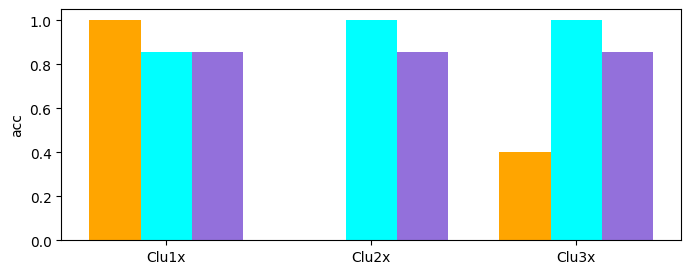

In [30]:
#3 each cluster effect to accuracy, keep only one clu each time, cluster inclusion

x_mean = np.mean(x_train,axis=0)
x = betas_concept[mkb].T
x = x[cat_idx2]
x = x - x_mean # centerize
print(x.shape) #(30,4510)

# coef = plsr.coef_ + 0
coef = wei + 0
coef[idxm_clux] = 0
coef_clu1x = coef + 0
coef_clu1x[idxm_clu3+idxm_clu2] = 0
y_pred_clu1x = np.dot(x, coef_clu1x.T)
coef_clu2x = coef + 0
coef_clu2x[idxm_clu1+idxm_clu3] = 0
y_pred_clu2x = np.dot(x, coef_clu2x.T)
coef_clu3x = coef + 0
coef_clu3x[idxm_clu1+idxm_clu2] = 0
y_pred_clu3x = np.dot(x, coef_clu3x.T)

# y_pred = plsr.predict(x)
# y_pred.T[idxm_clux] = 0
# y_pred_clu1x = y_pred+0
# y_pred_clu1x.T[idxm_clu3+idxm_clu2] = 0
# y_pred_clu2x = y_pred+0
# y_pred_clu2x.T[idxm_clu3+idxm_clu1] = 0
# y_pred_clu3x = y_pred+0
# y_pred_clu3x.T[idxm_clu1+idxm_clu2] = 0

id1 = []
id2 = []
id3 = []
for i in range(cats_num.shape[0]):
    if cats_num[i] == 0:
        id1.append(i)
    if cats_num[i] == 1:
        id2.append(i)
    if cats_num[i] == 2:
        id3.append(i)

#############################################1 img_fea_clu1x

X=y_pred_clu1x
print(X.shape)
Y=cats_num+0

y_hat = lr.predict(X)
Y = Y.reshape(-1)
result = y_hat == Y

acc_clu1x_1 = np.mean(result[id1])
# print('acc_clu1x: %.2f%%' % (100 * acc_clu1x_1))
acc_clu1x_2 = np.mean(result[id2])
# print('acc_clu1x: %.2f%%' % (100 * acc_clu1x_2))
acc_clu1x_3 = np.mean(result[id3])
# print('acc_clu1x: %.2f%%' % (100 * acc_clu1x_3))

################################################2 img_fea_clu2x

X=y_pred_clu2x
print(X.shape)
Y=cats_num+0

y_hat = lr.predict(X)
Y = Y.reshape(-1)
result = y_hat == Y

acc_clu2x_1 = np.mean(result[id1])
# print('acc_clu2x: %.2f%%' % (100 * acc_clu2x_1))
acc_clu2x_2 = np.mean(result[id2])
# print('acc_clu2x: %.2f%%' % (100 * acc_clu2x_2))
acc_clu2x_3 = np.mean(result[id3])
# print('acc_clu2x: %.2f%%' % (100 * acc_clu2x_3))

#################################################3 img_fea_clu3x

X=y_pred_clu3x
print(X.shape)
Y=cats_num+0

y_hat = lr.predict(X)
Y = Y.reshape(-1)
result = y_hat == Y

acc_clu3x_1 = np.mean(result[id1])
# print('acc_clu3x: %.2f%%' % (100 * acc_clu3x_1))
acc_clu3x_2 = np.mean(result[id2])
# print('acc_clu3x: %.2f%%' % (100 * acc_clu3x_2))
acc_clu3x_3 = np.mean(result[id3])
# print('acc_clu3x: %.2f%%' % (100 * acc_clu3x_3))

acc_ori = np.array([acc_ori_3,acc_ori_1,acc_ori_2])
acc_clux_ = np.array([[acc_clu2x_3,acc_clu2x_1,acc_clu2x_2],[acc_clu1x_3,acc_clu1x_1,acc_clu1x_2],[acc_clu3x_3,acc_clu3x_1,acc_clu3x_2]])
acc_clux = acc_clux_ + 0
for i in range(3):
    acc_clux[i] = acc_clux_[i] - acc_ori
print(acc_clux_)

xlb = ['Clu1x', 'Clu2x', 'Clu3x']
x = np.array([0,1.2,2.4])
# x = np.arange(len(xlb))
width = 0.3
ly2 = x - width
ly3 = x
ly4 = x + width

plt.figure(figsize=(8,3)) # ,dpi=300
plt.rc('font',family='Arial', size=10)
plt.bar(ly2,acc_clux_.T[0],width=width,color="orange",label='Sce') # ,yerr=std_score_bm
plt.bar(ly3,acc_clux_.T[1],width=width,color="cyan",label='Ani') #color=['orange','cyan','mediumpurple']
plt.bar(ly4,acc_clux_.T[2],width=width,color="mediumpurple",label='Obj')

font_dict = {'family':'Arial', 'size':10}
plt.xticks(x,labels=xlb,fontproperties=font_dict) # 
# plt.xlabel('Cluster',fontdict=font_dict)
plt.ylabel('acc',fontdict=font_dict)
# plt.legend(loc='best',prop=font_dict)
# plt.title('ROI prop selection') 
plt.show()

# plt.figure(figsize=(5,3)) # ,dpi=300
# plt.rc('font',family='Arial', size=10)
# plt.bar(ly2,acc_clux.T[0],width=width,color="orange",label='Sce') # ,yerr=std_score_bm
# plt.bar(ly3,acc_clux.T[1],width=width,color="cyan",label='Ani')
# plt.bar(ly4,acc_clux.T[2],width=width,color="mediumpurple",label='Obj')

# font_dict = {'family':'Arial', 'size':10}
# plt.xticks(x,labels=xlb,fontproperties=font_dict) # 
# # plt.xlabel('Cluster',fontdict=font_dict)
# plt.ylabel('$\Delta$ acc',fontdict=font_dict)
# # plt.legend(loc='best',prop=font_dict)
# # plt.title('ROI prop selection') 
# plt.show()
# plt.close()

In [27]:
# print(y_hat)
# print(Y)
coef_clu1x[idxm_clu3][10]

array([0., 0., 0., ..., 0., 0., 0.])

(19, 4510)
(19, 25088)
(19, 25088)
(19, 25088)
[[0.4        1.         0.85714286]
 [1.         0.85714286 0.85714286]
 [1.         1.         0.85714286]]


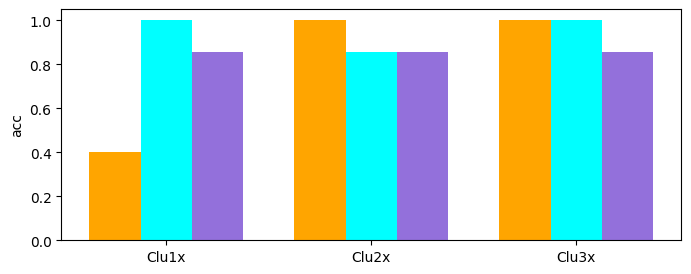

In [31]:
#4 cluster lesion to accuracy, cluster exclusion

# id = 7
# nm = lys[id]+'_b2m_plsr_label3.npz'
# yhat_ = np.load(pjoin(fdir, lys[id], nm))
# yhat = yhat_['label'] # [0,1,2]

x_mean = np.mean(x_train,axis=0)
x = betas_concept[mkb].T
x = x[cat_idx2]
x = x - x_mean # centerize
print(x.shape) #(30,4510)

coef = wei + 0 # plsr.coef_ + 0
coef[idxm_clux] = 0
coef_clu1x = coef + 0
coef_clu1x[idxm_clu1] = 0
y_pred_clu1x = np.dot(x, coef_clu1x.T)
coef_clu2x = coef + 0
coef_clu2x[idxm_clu2] = 0
y_pred_clu2x = np.dot(x, coef_clu2x.T)
coef_clu3x = coef + 0
coef_clu3x[idxm_clu3] = 0
y_pred_clu3x = np.dot(x, coef_clu3x.T)

# y_pred = plsr.predict(x)
# y_pred.T[idxm_clux] = 0
# y_pred_clu1x = y_pred+0
# y_pred_clu1x.T[idxm_clu1] = 0
# y_pred_clu2x = y_pred+0
# y_pred_clu2x.T[idxm_clu2] = 0
# y_pred_clu3x = y_pred+0
# y_pred_clu3x.T[idxm_clu3] = 0

id1 = []
id2 = []
id3 = []
for i in range(cats_num.shape[0]):
    if cats_num[i] == 0:
        id1.append(i)
    if cats_num[i] == 1:
        id2.append(i)
    if cats_num[i] == 2:
        id3.append(i)

#############################################1 img_fea_clu1x

X=y_pred_clu1x
print(X.shape)
Y=cats_num+0

y_hat = lr.predict(X)
Y = Y.reshape(-1)
result = y_hat == Y

acc_clu1x_1 = np.mean(result[id1])
# print('acc_clu1x: %.2f%%' % (100 * acc_clu1x_1))
acc_clu1x_2 = np.mean(result[id2])
# print('acc_clu1x: %.2f%%' % (100 * acc_clu1x_2))
acc_clu1x_3 = np.mean(result[id3])
# print('acc_clu1x: %.2f%%' % (100 * acc_clu1x_3))

################################################2 img_fea_clu2x

X=y_pred_clu2x
print(X.shape)
Y=cats_num+0

y_hat = lr.predict(X)
Y = Y.reshape(-1)
result = y_hat == Y

acc_clu2x_1 = np.mean(result[id1])
# print('acc_clu2x: %.2f%%' % (100 * acc_clu2x_1))
acc_clu2x_2 = np.mean(result[id2])
# print('acc_clu2x: %.2f%%' % (100 * acc_clu2x_2))
acc_clu2x_3 = np.mean(result[id3])
# print('acc_clu2x: %.2f%%' % (100 * acc_clu2x_3))

#################################################3 img_fea_clu3x

X=y_pred_clu3x
print(X.shape)
Y=cats_num+0

y_hat = lr.predict(X)
Y = Y.reshape(-1)
result = y_hat == Y

acc_clu3x_1 = np.mean(result[id1])
# print('acc_clu3x: %.2f%%' % (100 * acc_clu3x_1))
acc_clu3x_2 = np.mean(result[id2])
# print('acc_clu3x: %.2f%%' % (100 * acc_clu3x_2))
acc_clu3x_3 = np.mean(result[id3])
# print('acc_clu3x: %.2f%%' % (100 * acc_clu3x_3))

acc_ori = np.array([acc_ori_3,acc_ori_1,acc_ori_2])
acc_clux_ = np.array([[acc_clu2x_3,acc_clu2x_1,acc_clu2x_2],[acc_clu1x_3,acc_clu1x_1,acc_clu1x_2],[acc_clu3x_3,acc_clu3x_1,acc_clu3x_2]])
acc_clux = acc_clux_ + 0
for i in range(3):
    acc_clux[i] = acc_clux_[i] - acc_ori
print(acc_clux_)

xlb = ['Clu1x', 'Clu2x', 'Clu3x']
# x = np.arange(len(xlb))
x = np.array([0,1.2,2.4])
width = 0.3
ly2 = x - width
ly3 = x
ly4 = x + width

plt.figure(figsize=(8,3)) # ,dpi=300
plt.rc('font',family='Arial', size=10)
plt.bar(ly2,acc_clux_.T[0],width=width,color="orange",label='Sce') # ,yerr=std_score_bm
plt.bar(ly3,acc_clux_.T[1],width=width,color="cyan",label='Ani') #color=['orange','cyan','mediumpurple']
plt.bar(ly4,acc_clux_.T[2],width=width,color="mediumpurple",label='Obj')

font_dict = {'family':'Arial', 'size':10}
plt.xticks(x,labels=xlb,fontproperties=font_dict) # 
# plt.xlabel('Cluster',fontdict=font_dict)
plt.ylabel('acc',fontdict=font_dict)
# plt.legend(loc='best',prop=font_dict)
# plt.title('ROI prop selection') 
plt.show()

# plt.figure(figsize=(5,3)) # ,dpi=300
# plt.rc('font',family='Arial', size=10)
# plt.bar(ly2,acc_clux.T[0],width=width,color="orange",label='Sce') # ,yerr=std_score_bm
# plt.bar(ly3,acc_clux.T[1],width=width,color="cyan",label='Ani')
# plt.bar(ly4,acc_clux.T[2],width=width,color="mediumpurple",label='Obj')

# font_dict = {'family':'Arial', 'size':10}
# plt.xticks(x,labels=xlb,fontproperties=font_dict) # 
# # plt.xlabel('Cluster',fontdict=font_dict)
# plt.ylabel('$\Delta$ acc',fontdict=font_dict)
# plt.ylim((-1,0))
# # plt.legend(loc='best',prop=font_dict)
# # plt.title('ROI prop selection') 
# plt.show()
# plt.close()

(19, 4510)
(19, 25088)
acc_pred_ani: 100.00%
acc_pred_obj: 85.71%
acc_pred_sce: 100.00%
[1.         1.         0.85714286]


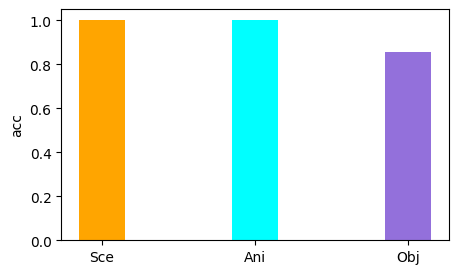

In [ ]:
# # effect of idxm_clux to classification
# # plsr
# x_mean = np.mean(x_train,axis=0)
# x = betas_concept[mkb].T
# x = x[cat_idx2]
# x = x - x_mean # centerize
# print(x.shape) #(30,4510)
# coef = plsr.coef_ + 0
# coef[idxm_clu1+idxm_clu2+idxm_clu3]=0
# y_pred = np.dot(x, coef.T)
# # y_pred = plsr.predict(x)
# # y_pred.T[idxm_clux] = 0

# # classifier
# X=y_pred
# print(X.shape)
# Y=cats_num+0

# y_hat = lr.predict(X)
# Y = Y.reshape(-1)
# result = y_hat == Y

# id1 = []
# id2 = []
# id3 = []
# for i in range(Y.shape[0]):
#     if Y[i] == 0:
#         id1.append(i)
#     if Y[i] == 1:
#         id2.append(i)
#     if Y[i] == 2:
#         id3.append(i)

# acc_clux_1 = np.mean(result[id1])
# print('acc_pred_ani: %.2f%%' % (100 * acc_clux_1))
# acc_clux_2 = np.mean(result[id2])
# print('acc_pred_obj: %.2f%%' % (100 * acc_clux_2))
# acc_clux_3 = np.mean(result[id3])
# print('acc_pred_sce: %.2f%%' % (100 * acc_clux_3))

# acc_clux = np.array([acc_clux_3, acc_clux_1, acc_clux_2])
# print(acc_clux)

# x = np.arange(3)
# xlb = ['Sce', 'Ani', 'Obj']
# width = 0.3

# plt.figure(figsize=(5,3)) # ,dpi=300
# plt.rc('font',family='Arial', size=10)

# plt.bar(x,acc_clux,width=width,color=['orange','cyan','mediumpurple']) # ,yerr=std_score_bm,

# font_dict = {'family':'Arial', 'size':10}
# plt.xticks(x,labels=xlb,fontproperties=font_dict) # 
# # plt.xlabel('Cluster',fontdict=font_dict)
# plt.ylabel('acc',fontdict=font_dict)
# # plt.legend(loc='best',prop=font_dict)
# # plt.title('ROI prop selection') 
# plt.show()
# plt.close()

(19, 4510)
(19, 25088)
(19, 25088)
(19, 25088)
[[0. 1. 0.]
 [0. 0. 1.]
 [1. 0. 0.]]


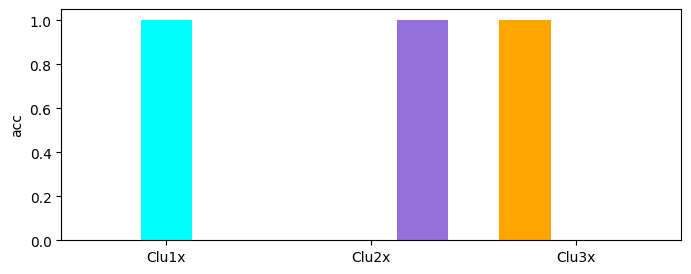

In [38]:
#3 cluster inhibition to accuracy xxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxx

# id = 7
# nm = lys[id]+'_b2m_plsr_label3.npz'
# yhat_ = np.load(pjoin(fdir, lys[id], nm))
# yhat = yhat_['label'] # [0,1,2]

x_mean = np.mean(x_train,axis=0)
x = betas_concept[mkb].T
x = x[cat_idx2]
x = x - x_mean # centerize
print(x.shape) #(30,4510)

coef = wei + 0 # plsr.coef_ + 0
coef[idxm_clux] = 0
coef_clu1x = coef + 0
coef_clu1x[idxm_clu1] = -0.02
y_pred_clu1x = np.dot(x, coef_clu1x.T)
coef_clu2x = coef + 0
coef_clu2x[idxm_clu2] = -0.02
y_pred_clu2x = np.dot(x, coef_clu2x.T)
coef_clu3x = coef + 0
coef_clu3x[idxm_clu3] = -0.02
y_pred_clu3x = np.dot(x, coef_clu3x.T)

id1 = []
id2 = []
id3 = []
for i in range(cats_num.shape[0]):
    if cats_num[i] == 0:
        id1.append(i)
    if cats_num[i] == 1:
        id2.append(i)
    if cats_num[i] == 2:
        id3.append(i)

#############################################1 img_fea_clu1x

X=y_pred_clu1x
print(X.shape)
Y=cats_num+0

y_hat = lr.predict(X)
Y = Y.reshape(-1)
result = y_hat == Y

acc_clu1x_1 = np.mean(result[id1])
# print('acc_clu1x: %.2f%%' % (100 * acc_clu1x_1))
acc_clu1x_2 = np.mean(result[id2])
# print('acc_clu1x: %.2f%%' % (100 * acc_clu1x_2))
acc_clu1x_3 = np.mean(result[id3])
# print('acc_clu1x: %.2f%%' % (100 * acc_clu1x_3))

################################################2 img_fea_clu2x

X=y_pred_clu2x
print(X.shape)
Y=cats_num+0

y_hat = lr.predict(X)
Y = Y.reshape(-1)
result = y_hat == Y

acc_clu2x_1 = np.mean(result[id1])
# print('acc_clu2x: %.2f%%' % (100 * acc_clu2x_1))
acc_clu2x_2 = np.mean(result[id2])
# print('acc_clu2x: %.2f%%' % (100 * acc_clu2x_2))
acc_clu2x_3 = np.mean(result[id3])
# print('acc_clu2x: %.2f%%' % (100 * acc_clu2x_3))

#################################################3 img_fea_clu3x

X=y_pred_clu3x
print(X.shape)
Y=cats_num+0

y_hat = lr.predict(X)
Y = Y.reshape(-1)
result = y_hat == Y

acc_clu3x_1 = np.mean(result[id1])
# print('acc_clu3x: %.2f%%' % (100 * acc_clu3x_1))
acc_clu3x_2 = np.mean(result[id2])
# print('acc_clu3x: %.2f%%' % (100 * acc_clu3x_2))
acc_clu3x_3 = np.mean(result[id3])
# print('acc_clu3x: %.2f%%' % (100 * acc_clu3x_3))

acc_ori = np.array([acc_ori_3,acc_ori_1,acc_ori_2])
acc_clux_ = np.array([[acc_clu2x_3,acc_clu2x_1,acc_clu2x_2],[acc_clu1x_3,acc_clu1x_1,acc_clu1x_2],[acc_clu3x_3,acc_clu3x_1,acc_clu3x_2]])
acc_clux = acc_clux_ + 0
for i in range(3):
    acc_clux[i] = acc_clux_[i] - acc_ori
print(acc_clux_)

xlb = ['Clu1x', 'Clu2x', 'Clu3x']
x = np.array([0,1.2,2.4])
width = 0.3
ly2 = x - width
ly3 = x
ly4 = x + width

plt.figure(figsize=(8,3)) # ,dpi=300
plt.rc('font',family='Arial', size=10)
plt.bar(ly2,acc_clux_.T[0],width=width,color="orange",label='Sce') # ,yerr=std_score_bm
plt.bar(ly3,acc_clux_.T[1],width=width,color="cyan",label='Ani')
plt.bar(ly4,acc_clux_.T[2],width=width,color="mediumpurple",label='Obj')

font_dict = {'family':'Arial', 'size':10}
plt.xticks(x,labels=xlb,fontproperties=font_dict) # 
# plt.xlabel('Cluster',fontdict=font_dict)
plt.ylabel('acc',fontdict=font_dict)
# plt.legend(loc='best',prop=font_dict)
# plt.title('ROI prop selection') 
plt.show()

# plt.figure(figsize=(5,3)) # ,dpi=300
# plt.rc('font',family='Arial', size=10)
# plt.bar(ly2,acc_clux.T[0],width=width,color="orange",label='Sce') # ,yerr=std_score_bm
# plt.bar(ly3,acc_clux.T[1],width=width,color="cyan",label='Ani')
# plt.bar(ly4,acc_clux.T[2],width=width,color="mediumpurple",label='Obj')

# font_dict = {'family':'Arial', 'size':10}
# plt.xticks(x,labels=xlb,fontproperties=font_dict) # 
# # plt.xlabel('Cluster',fontdict=font_dict)
# plt.ylabel('$\Delta$ acc',fontdict=font_dict)
# # plt.legend(loc='best',prop=font_dict)
# # plt.title('ROI prop selection') 
# plt.show()
# plt.close()

(19, 25088)
1.063913358940523 9.472744935420163 -1.30399990082842


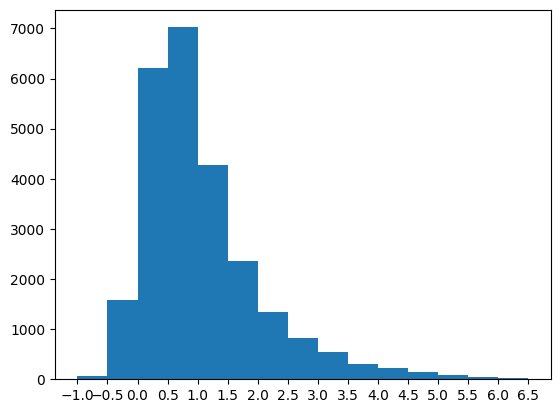

In [ ]:
# distribution of plsr.predict img features
print(y_pred.shape)
IDX=7
print(np.mean(y_pred[IDX]),np.max(y_pred[IDX]),np.min(y_pred[IDX]))

d = 0.5
num_bin = np.arange(-1,7,d)
#print(max(a)-min(a),max(a),min(a))

plt.figure() # figsize=(16,6),dpi=80

plt.hist(y_pred[IDX], num_bin)
plt.xticks(num_bin)
plt.show()

(19, 4510)
(19, 25088)
(19, 25088)
(19, 25088)
[[1.         0.         0.        ]
 [0.         1.         0.        ]
 [0.         0.14285714 1.        ]]


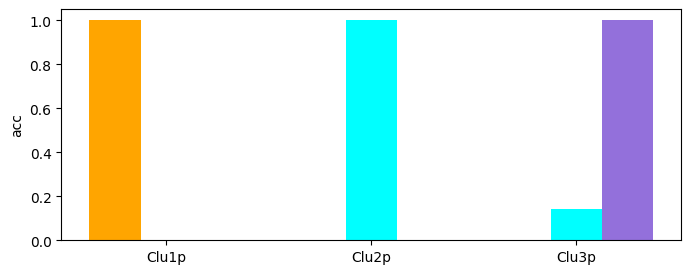

In [39]:
#3 cluster strengthen to accuracy

# id = 7
# nm = lys[id]+'_b2m_plsr_label3.npz'
# yhat_ = np.load(pjoin(fdir, lys[id], nm))
# yhat = yhat_['label'] # [0,1,2]

x_mean = np.mean(x_train,axis=0)
x = betas_concept[mkb].T
x = x[cat_idx2]
x = x - x_mean # centerize
print(x.shape) #(30,4510)

coef = wei + 0
coef[idxm_clux] = 0
coef_clu1p = coef + 0
coef_clu1p[idxm_clu1] = 0.02
y_pred_clu1p = np.dot(x, coef_clu1p.T)
coef_clu2p = coef + 0
coef_clu2p[idxm_clu2] = 0.02
y_pred_clu2p = np.dot(x, coef_clu2p.T)
coef_clu3p = coef + 0
coef_clu3p[idxm_clu3] = 0.02
y_pred_clu3p = np.dot(x, coef_clu3p.T)

# y_pred = plsr.predict(x)
# y_pred.T[idxm_clux] = 0
# y_pred_clu1p = y_pred+0
# y_pred_clu1p.T[idxm_clu1] = 6
# y_pred_clu2p = y_pred+0
# y_pred_clu2p.T[idxm_clu2] = 6
# y_pred_clu3p = y_pred+0
# y_pred_clu3p.T[idxm_clu3] = 6

id1 = []
id2 = []
id3 = []
for i in range(cats_num.shape[0]):
    if cats_num[i] == 0:
        id1.append(i)
    if cats_num[i] == 1:
        id2.append(i)
    if cats_num[i] == 2:
        id3.append(i)

y_hat_ = [] # store lr.predict
#############################################1 img_fea_clu1x

X=y_pred_clu1p
print(X.shape)
Y=cats_num+0

y_hat = lr.predict(X)
y_hat_.append(y_hat)
Y = Y.reshape(-1)
result = y_hat == Y

acc_clu1p_1 = np.mean(result[id1])
# print('acc_clu1x: %.2f%%' % (100 * acc_clu1x_1))
acc_clu1p_2 = np.mean(result[id2])
# print('acc_clu1x: %.2f%%' % (100 * acc_clu1x_2))
acc_clu1p_3 = np.mean(result[id3])
# print('acc_clu1x: %.2f%%' % (100 * acc_clu1x_3))

################################################2 img_fea_clu2x

X=y_pred_clu2p
print(X.shape)
Y=cats_num+0

y_hat = lr.predict(X)
y_hat_.append(y_hat)
Y = Y.reshape(-1)
result = y_hat == Y

acc_clu2p_1 = np.mean(result[id1])
# print('acc_clu2x: %.2f%%' % (100 * acc_clu2x_1))
acc_clu2p_2 = np.mean(result[id2])
# print('acc_clu2x: %.2f%%' % (100 * acc_clu2x_2))
acc_clu2p_3 = np.mean(result[id3])
# print('acc_clu2x: %.2f%%' % (100 * acc_clu2x_3))

#################################################3 img_fea_clu3x

X=y_pred_clu3p
print(X.shape)
Y=cats_num+0

y_hat = lr.predict(X)
y_hat_.append(y_hat)
Y = Y.reshape(-1)
result = y_hat == Y

acc_clu3p_1 = np.mean(result[id1])
# print('acc_clu3x: %.2f%%' % (100 * acc_clu3x_1))
acc_clu3p_2 = np.mean(result[id2])
# print('acc_clu3x: %.2f%%' % (100 * acc_clu3x_2))
acc_clu3p_3 = np.mean(result[id3])
# print('acc_clu3x: %.2f%%' % (100 * acc_clu3x_3))

acc_ori = np.array([acc_ori_3,acc_ori_1,acc_ori_2])
acc_clup_ = np.array([[acc_clu2p_3,acc_clu2p_1,acc_clu2p_2],[acc_clu1p_3,acc_clu1p_1,acc_clu1p_2],[acc_clu3p_3,acc_clu3p_1,acc_clu3p_2]])
acc_clup = acc_clup_ + 0
for i in range(3):
    acc_clup[i] = acc_clup_[i] - acc_ori
print(acc_clup_)

xlb = ['Clu1p', 'Clu2p', 'Clu3p']
# x = np.arange(len(xlb))
x = np.array([0,1.2,2.4])
width = 0.3
ly2 = x - width
ly3 = x
ly4 = x + width

plt.figure(figsize=(8,3)) # ,dpi=300
plt.rc('font',family='Arial', size=10)
plt.bar(ly2,acc_clup_.T[0],width=width,color="orange",label='Sce') # ,yerr=std_score_bm
plt.bar(ly3,acc_clup_.T[1],width=width,color="cyan",label='Ani') #color=['orange','cyan','mediumpurple']
plt.bar(ly4,acc_clup_.T[2],width=width,color="mediumpurple",label='Obj')

font_dict = {'family':'Arial', 'size':10}
plt.xticks(x,labels=xlb,fontproperties=font_dict) # 
# plt.xlabel('Cluster',fontdict=font_dict)
plt.ylabel('acc',fontdict=font_dict)
# plt.ylabel('$\Delta$ acc',fontdict=font_dict)
# plt.legend(loc='best',prop=font_dict)
# plt.title('ROI prop selection') 
plt.show()

# plt.figure(figsize=(5,3)) # ,dpi=300
# plt.rc('font',family='Arial', size=10)
# plt.bar(ly2,acc_clup.T[0],width=width,color="orange",label='Sce') # ,yerr=std_score_bm
# plt.bar(ly3,acc_clup.T[1],width=width,color="cyan",label='Ani')
# plt.bar(ly4,acc_clup.T[2],width=width,color="mediumpurple",label='Obj')

# font_dict = {'family':'Arial', 'size':10}
# plt.xticks(x,labels=xlb,fontproperties=font_dict) # 
# # plt.xlabel('Cluster',fontdict=font_dict)
# plt.ylabel('$\Delta$ acc',fontdict=font_dict)
# # plt.legend(loc='best',prop=font_dict)
# # plt.title('ROI prop selection') 
# plt.show()
# plt.close()

In [23]:
print(y_hat_)

[array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]), array([2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2]), array([1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1])]


(19, 4510)
(19, 25088)
(19, 25088)
(19, 25088)
(19, 25088)
(19, 25088)
(19, 25088)
(19, 25088)
(19, 25088)
(19, 25088)
(19, 25088)
(19, 25088)
operation on clu1


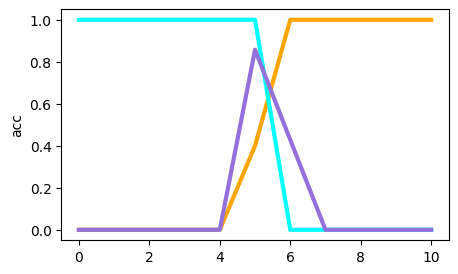

operation on clu2


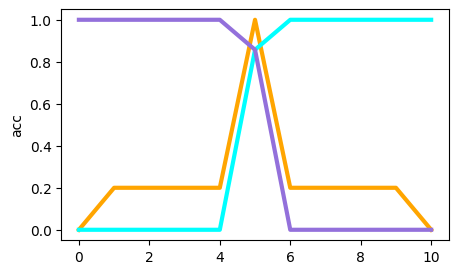

operation on clu3


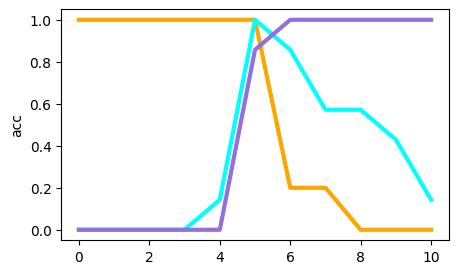

In [52]:
# classification performance with cluster change from inhibition to activation along a gradient
x_mean = np.mean(x_train,axis=0)
x = betas_concept[mkb].T
x = x[cat_idx2]
x = x - x_mean # centerize
print(x.shape) #(30,4510)

def gradact(x,val):

    coef = wei + 0
    coef[idxm_clux] = 0
    coef_clu1p = coef + 0
    coef_clu1p[idxm_clu1] = val
    y_pred_clu1p = np.dot(x, coef_clu1p.T)
    coef_clu2p = coef + 0
    coef_clu2p[idxm_clu2] = val
    y_pred_clu2p = np.dot(x, coef_clu2p.T)
    coef_clu3p = coef + 0
    coef_clu3p[idxm_clu3] = val
    y_pred_clu3p = np.dot(x, coef_clu3p.T)

    id1 = []
    id2 = []
    id3 = []
    for i in range(cats_num.shape[0]):
        if cats_num[i] == 0:
            id1.append(i)
        if cats_num[i] == 1:
            id2.append(i)
        if cats_num[i] == 2:
            id3.append(i)

    y_hat_ = [] # store lr.predict
    #############################################1 img_fea_clu1x

    X=y_pred_clu1p
    print(X.shape)
    Y=cats_num+0

    y_hat = lr.predict(X)
    y_hat_.append(y_hat)
    Y = Y.reshape(-1)
    result = y_hat == Y

    acc_clu1p_1 = np.mean(result[id1])
    # print('acc_clu1x: %.2f%%' % (100 * acc_clu1x_1))
    acc_clu1p_2 = np.mean(result[id2])
    # print('acc_clu1x: %.2f%%' % (100 * acc_clu1x_2))
    acc_clu1p_3 = np.mean(result[id3])
    # print('acc_clu1x: %.2f%%' % (100 * acc_clu1x_3))

    ################################################2 img_fea_clu2x

    X=y_pred_clu2p
    # print(X.shape)
    Y=cats_num+0

    y_hat = lr.predict(X)
    y_hat_.append(y_hat)
    Y = Y.reshape(-1)
    result = y_hat == Y

    acc_clu2p_1 = np.mean(result[id1])
    # print('acc_clu2x: %.2f%%' % (100 * acc_clu2x_1))
    acc_clu2p_2 = np.mean(result[id2])
    # print('acc_clu2x: %.2f%%' % (100 * acc_clu2x_2))
    acc_clu2p_3 = np.mean(result[id3])
    # print('acc_clu2x: %.2f%%' % (100 * acc_clu2x_3))

    #################################################3 img_fea_clu3x

    X=y_pred_clu3p
    # print(X.shape)
    Y=cats_num+0

    y_hat = lr.predict(X)
    y_hat_.append(y_hat)
    Y = Y.reshape(-1)
    result = y_hat == Y

    acc_clu3p_1 = np.mean(result[id1])
    # print('acc_clu3x: %.2f%%' % (100 * acc_clu3x_1))
    acc_clu3p_2 = np.mean(result[id2])
    # print('acc_clu3x: %.2f%%' % (100 * acc_clu3x_2))
    acc_clu3p_3 = np.mean(result[id3])
    # print('acc_clu3x: %.2f%%' % (100 * acc_clu3x_3))

    # acc_ori = np.array([acc_ori_3,acc_ori_1,acc_ori_2])
    acc_clu1p_ = np.array([acc_clu2p_3,acc_clu2p_1,acc_clu2p_2])
    acc_clu2p_ = np.array([acc_clu1p_3,acc_clu1p_1,acc_clu1p_2])
    acc_clu3p_ = np.array([acc_clu3p_3,acc_clu3p_1,acc_clu3p_2])
    return acc_clu1p_, acc_clu2p_, acc_clu3p_

def plot(acc_clup_):
    # xlb = ['Clu1', 'Clu2', 'Clu3']
    # x = np.arange(len(xlb))
    x = np.arange(acc_clup_.shape[0])
   

    plt.figure(figsize=(5,3)) # ,dpi=300
    plt.rc('font',family='Arial', size=10)
    plt.plot(x,acc_clup_.T[0],color="orange",label='Sce',linewidth=3) # ,yerr=std_score_bm
    plt.plot(x,acc_clup_.T[1],color="cyan",label='Ani',linewidth=3) #color=['orange','cyan','mediumpurple']
    plt.plot(x,acc_clup_.T[2],color="mediumpurple",label='Obj',linewidth=3)

    font_dict = {'family':'Arial', 'size':10}
    # plt.xticks(x,fontproperties=font_dict) # labels=xlb,
    # plt.xlabel('Cluster',fontdict=font_dict)
    plt.ylabel('acc',fontdict=font_dict)
    # plt.ylabel('$\Delta$ acc',fontdict=font_dict)
    # plt.legend(loc='best',prop=font_dict)
    # plt.title('ROI prop selection') 
    plt.show()

acc_clu1p = []
acc_clu2p = []
acc_clu3p = []
val_ = np.arange(-0.02,0.021,0.004) # (-0.02,0.02,0.004)
for i in range(val_.shape[0]):
    x1,x2,x3 = gradact(x,val_[i])
    acc_clu1p.append(x1)
    acc_clu2p.append(x2)
    acc_clu3p.append(x3)

print('operation on clu1')
plot(np.array(acc_clu1p))
print('operation on clu2')
plot(np.array(acc_clu2p))
print('operation on clu3')
plot(np.array(acc_clu3p))



In [ ]:
################################################################################################################# end